# Análisis Exploratorio de Datos, EDA
***Diplomado en Estadística Aplicada a la Toma de Deciciones, 3ra versión***

Estudiante: Neil Iver Inclan Piérola

Se realizará el **Análisis Exploratorio de Datos** correspondiende con los datos proporcionados por la Cooperativa "CACEF", el objetivo será revisar la calidad de los datos, conocer los patrones de este conjunto de datos, y crear la variable objetivo.

# Prepación del entorno de trabajo

## Importación de las liberías

In [1]:
#!pip install openpyxl

In [2]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import ListedColormap
import seaborn as sns
import scipy.stats as stats

# Mostrar gráficos en línea y adoptar un estilo
%matplotlib inline
sns.set_style("whitegrid")

# Formatear numeros
pd.options.display.float_format = '{:,.0f}'.format

## Cargado de datos

In [3]:
df_default = pd.read_excel('Requerimiento_Externo_Cacef.xlsx')
df_default.head()

,id_credito,id_socio,fecha_desembolso,fecha_vencimiento,tasa_interes,moneda,forma_pago,periodo_amortizacion,cuotas_pactadas,periodo_pago_interes,...,id_agencia,fecha_nacimiento,numero_creditos,genero,estado_civil,ingresos_anual,gastos_anual,departamento,actividad_economica,antiguedad_actividad
0,360222,49120,2017-07-01,2018-06-11,16,BOLIVIANOS,AMORTIZABLE,MENSUAL,11,30,...,36,1985-10-26,1,MASCULINO,CASADO(A),"48,000","15,540",ORURO,TRANSPORTISTA,10
1,360304,49256,2017-10-19,2026-03-20,13,BOLIVIANOS,CUOTA FIJA,MENSUAL,60,30,...,36,1980-02-29,1,MASCULINO,CASADO(A),"163,709","99,115",COCHABAMBA,INDEPENDIENTE,13
2,360321,49124,2017-11-17,2034-03-20,13,BOLIVIANOS,CUOTA FIJA,MENSUAL,114,30,...,36,1983-10-22,2,MASCULINO,CASADO(A),"121,234",0,COCHABAMBA,TRANSPORTISTA,7
3,360323,48670,2017-11-24,2028-07-15,15,BOLIVIANOS,CUOTA FIJA,MENSUAL,43,30,...,36,1983-02-13,6,MASCULINO,SOLTERO(A),"86,023","12,000",COCHABAMBA,INDEPENDIENTE,10
4,360338,50726,2017-12-26,2026-11-16,15,BOLIVIANOS,CUOTA FIJA,MENSUAL,60,30,...,36,1965-02-07,1,MASCULINO,SOLTERO(A),"82,880","46,336",COCHABAMBA,INDEPENDIENTE,10


In [4]:
# Para verificar el formato de los datos
df_default.shape

(5247, 34)

# Exploración Inicial

## Información general

In [5]:
# Convierte ids en tipo object
df_default[['id_credito', 'id_socio', 'id_agencia']] = df_default[['id_credito', 'id_socio', 'id_agencia']].astype('object')
df_default.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5247 entries, 0 to 5246
Data columns (total 34 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id_credito            5247 non-null   object        
 1   id_socio              5247 non-null   object        
 2   fecha_desembolso      5247 non-null   datetime64[ns]
 3   fecha_vencimiento     5247 non-null   datetime64[ns]
 4   tasa_interes          5247 non-null   float64       
 5   moneda                5247 non-null   object        
 6   forma_pago            5247 non-null   object        
 7   periodo_amortizacion  5247 non-null   object        
 8   cuotas_pactadas       5247 non-null   int64         
 9   periodo_pago_interes  5247 non-null   int64         
 10  monto_desembolso      5247 non-null   float64       
 11  saldo_credito         5247 non-null   float64       
 12  tipo_cambio           5247 non-null   float64       
 13  monto_diferido_bs 

Se puede ver que los únicos campos que tienen valores nulos son los ingresos y gastos a nivel anual declarados por el cliente.

## Creación de la variable objetivo
Como se ha mencionado antes, la variable objetivo será una variable booleana, dónde el 1 representará el incumplimiento del crédito y 0 su cumplimiento.

El criterio para asignar esta variable serán los días de mora, si un crédito tiene 50 días de mora o más, será considerado como default.

In [6]:
df_default['default'] = np.where(df_default['dias_mora'] >= 50, 1, 0)
df_default.head()

,id_credito,id_socio,fecha_desembolso,fecha_vencimiento,tasa_interes,moneda,forma_pago,periodo_amortizacion,cuotas_pactadas,periodo_pago_interes,...,fecha_nacimiento,numero_creditos,genero,estado_civil,ingresos_anual,gastos_anual,departamento,actividad_economica,antiguedad_actividad,default
0,360222,49120,2017-07-01,2018-06-11,16,BOLIVIANOS,AMORTIZABLE,MENSUAL,11,30,...,1985-10-26,1,MASCULINO,CASADO(A),"48,000","15,540",ORURO,TRANSPORTISTA,10,1
1,360304,49256,2017-10-19,2026-03-20,13,BOLIVIANOS,CUOTA FIJA,MENSUAL,60,30,...,1980-02-29,1,MASCULINO,CASADO(A),"163,709","99,115",COCHABAMBA,INDEPENDIENTE,13,0
2,360321,49124,2017-11-17,2034-03-20,13,BOLIVIANOS,CUOTA FIJA,MENSUAL,114,30,...,1983-10-22,2,MASCULINO,CASADO(A),"121,234",0,COCHABAMBA,TRANSPORTISTA,7,0
3,360323,48670,2017-11-24,2028-07-15,15,BOLIVIANOS,CUOTA FIJA,MENSUAL,43,30,...,1983-02-13,6,MASCULINO,SOLTERO(A),"86,023","12,000",COCHABAMBA,INDEPENDIENTE,10,0
4,360338,50726,2017-12-26,2026-11-16,15,BOLIVIANOS,CUOTA FIJA,MENSUAL,60,30,...,1965-02-07,1,MASCULINO,SOLTERO(A),"82,880","46,336",COCHABAMBA,INDEPENDIENTE,10,0


In [7]:
# Adicionalmente se crearán las variables de edad en años y de duracion programada del crédito en meses
# fecha de corte 31/01/2025
ref = pd.Timestamp('2025-01-31')

# Calcular la edad del socio:
df_default['edad'] = df_default['fecha_nacimiento'].apply(
    lambda d: (ref.year - d.year) - ((ref.month, ref.day) < (d.month, d.day)) if pd.notnull(d) else np.nan
)

# Calcular la duración del crédito en meses (fecha_vencimiento - fecha_desembolso) / 30.4 meses aproximados:
df_default['duracion_credito'] = ((df_default['fecha_vencimiento'] - df_default['fecha_desembolso']).dt.days) / 30.4
df_default['duracion_credito'].round()

df_default.describe(include=[np.number])

,tasa_interes,cuotas_pactadas,periodo_pago_interes,monto_desembolso,saldo_credito,tipo_cambio,monto_diferido_bs,monto_diferido_usd,interes_diferido_bs,interes_diferido_usd,dias_mora,monto_garantia_bs,monto_favor_bs,numero_creditos,ingresos_anual,gastos_anual,antiguedad_actividad,default,edad,duracion_credito
count,"5,247","5,247","5,247","5,247","5,247","5,247","5,247","5,247","5,247","5,247","5,247","5,247","5,247","5,247","5,201","5,201","5,247","5,247","5,247","5,247"
mean,14,34,126,"88,296","55,208",7,"1,749",1,"1,300",1,17,"126,679","42,075",3,"140,533","74,151",15,0,44,61
std,4,29,125,"94,498","69,462",0,"6,297",52,"5,178",57,169,"639,775","128,911",3,"520,991","646,595",11,0,13,24
min,7,1,30,"3,500",0,7,0,0,0,0,0,0,0,1,0,0,0,0,19,6
25%,11,10,30,"35,000","18,986",7,0,0,0,0,0,0,0,1,"34,560","12,000",5,0,33,49
50%,12,20,90,"70,000","38,059",7,0,0,0,0,0,0,0,2,"66,000","26,500",11,0,43,60
75%,14,60,180,"105,000","65,331",7,0,0,0,0,0,0,0,4,"117,800","52,800",21,0,53,61
max,22,187,360,"1,000,000","997,958",7,"75,351","3,582","65,022","4,089","4,039","40,133,788","4,230,808",57,"27,381,403","40,153,259",54,1,87,285


Para las variables numéricas se puede observar que:
*   En promedio un crédito es de Bs 88,296, con 14% de interes, y tiene una duración de 61 meses,
*   Los clientes en promedio tienen 44 años de edad, han tenido 3 créditos anteriormente y tienen una mediana de Bs 66,000 de ingresos y Bs 26,500 gastos por año respectivamente,
*   Los días de mora promedio de los créditos son de 17, con una desviación estándar de 169 días, lo que indica una variabilidad muy alta, y al ver los demás cuartiles en 0, significa que la gran mayoría de créditos se pagan oportunamente.



In [8]:
df_default.describe(include=['datetime'])

,fecha_desembolso,fecha_vencimiento,fecha_incumplimiento,fecha_nacimiento
count,5247,5247,5247,5247
mean,2022-09-23 06:34:38.902230016,2027-10-31 17:15:28.301886976,1903-07-22 15:47:06.072040960,1981-01-09 21:47:10.188679232
min,2012-05-28 00:00:00,2017-06-10 00:00:00,1900-01-01 00:00:00,1938-01-24 00:00:00
25%,2021-11-29 12:00:00,2026-09-15 00:00:00,1900-01-01 00:00:00,1971-08-17 12:00:00
50%,2023-03-17 00:00:00,2027-09-15 00:00:00,1900-01-01 00:00:00,1982-01-28 00:00:00
75%,2024-02-28 00:00:00,2028-11-16 00:00:00,1900-01-01 00:00:00,1991-07-30 00:00:00
max,2025-01-31 00:00:00,2039-12-02 00:00:00,2025-01-20 00:00:00,2005-07-02 00:00:00


Para las variables de fecha, se puede ver que:

*   Se tiene una cobertura de datos desde el desde mayo de 2012 hasta el 31 de enero del 2025
*   En promedio los créditos se venceran el 2027



In [9]:
df_default.describe(include=['object'])

,id_credito,id_socio,moneda,forma_pago,periodo_amortizacion,estado,tipo_credito,destino_credito,id_agencia,genero,estado_civil,departamento,actividad_economica
count,5247,5247,5247,5247,5247,5247,5247,5247,5247,5247,5247,5247,5247
unique,5247,4565,2,3,6,3,9,6,6,2,5,6,11
top,3601423,46639,BOLIVIANOS,CUOTA FIJA,MENSUAL,VIGENTE,MICRO.AGROPECUARIO ...,CAPITAL DE INVE,34,MASCULINO,CASADO(A),COCHABAMBA,INDEPENDIENTE
freq,1,8,5204,4614,2359,5144,2319,3223,1207,3957,3183,4980,4423


En cuanto a las variables de texto, se ve lo siguiente:

*   Hay **5247 créditos únicos**, que corresponden a **4565 socios de la cooperativa**, la gran **mayoría** de estos créditos están en **moneda nacional** y se **amortizan mensualmente** mediante **cuotas fijas**.
*   Al rededor de **la mitad** se destinan como **Capital de Inversión** y se otorgan como **microcréditos** al **sector agropecuario**
*   Los **clientes** en su **mayoría** son **varones**, están **casados**, habitan en **Cochabamba** y mantienen un **negocio propio** (independientes)



## Eliminación de variables redundantes

*   Se filtrará el conjunto de datos para los créditos en moneda nacional, debido a que representan un 99% de los créditos otorgados, por esta razón se eliminará los montos en dolares de la tabla: moneda, monto_diferido_usd, interes_diferido_usd, tipo_cambio.
*   Se eliminará la fecha de incumplimiento, dado que los días de mora son calculados con la diferencia entre la fecha de corte y esta fecha.
*   Se eliminará la fecha de nacimiento dado que ya se calculó la edad del cliente.





In [10]:
# Histograma de cuantos creditos tiene un cliente,
# filtrar el campo moneda para que solo haya créditos en bolivianos
df_default = df_default.loc[df_default['moneda'] == 'BOLIVIANOS']

# borrar moneda, monto diferido usd, interes diferido usd, tipo de cambio, fecha incumplimiento y fecha nacimiento
df_default.drop(['moneda', 'monto_diferido_usd', 'interes_diferido_usd', 'tipo_cambio', 'fecha_incumplimiento', 'fecha_nacimiento'], axis=1, inplace=True)

df_default.head()

<ipython-input-10-027641f330f2>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_default.drop(['moneda', 'monto_diferido_usd', 'interes_diferido_usd', 'tipo_cambio', 'fecha_incumplimiento', 'fecha_nacimiento'], axis=1, inplace=True)


,id_credito,id_socio,fecha_desembolso,fecha_vencimiento,tasa_interes,forma_pago,periodo_amortizacion,cuotas_pactadas,periodo_pago_interes,monto_desembolso,...,genero,estado_civil,ingresos_anual,gastos_anual,departamento,actividad_economica,antiguedad_actividad,default,edad,duracion_credito
0,360222,49120,2017-07-01,2018-06-11,16,AMORTIZABLE,MENSUAL,11,30,"7,333",...,MASCULINO,CASADO(A),"48,000","15,540",ORURO,TRANSPORTISTA,10,1,39,11
1,360304,49256,2017-10-19,2026-03-20,13,CUOTA FIJA,MENSUAL,60,30,"160,000",...,MASCULINO,CASADO(A),"163,709","99,115",COCHABAMBA,INDEPENDIENTE,13,0,44,101
2,360321,49124,2017-11-17,2034-03-20,13,CUOTA FIJA,MENSUAL,114,30,"165,000",...,MASCULINO,CASADO(A),"121,234",0,COCHABAMBA,TRANSPORTISTA,7,0,41,196
3,360323,48670,2017-11-24,2028-07-15,15,CUOTA FIJA,MENSUAL,43,30,"70,000",...,MASCULINO,SOLTERO(A),"86,023","12,000",COCHABAMBA,INDEPENDIENTE,10,0,41,128
4,360338,50726,2017-12-26,2026-11-16,15,CUOTA FIJA,MENSUAL,60,30,"56,000",...,MASCULINO,SOLTERO(A),"82,880","46,336",COCHABAMBA,INDEPENDIENTE,10,0,59,107


In [11]:
# formatear variables todas las variables object
for col in df_default.select_dtypes(include=['object']):
    # borrar espacios innecesarios, title case (JUAN -> Juan)
    df_default.loc[:, col] = df_default[col].astype(str).str.strip().str.title()

In [12]:
# describe de las variables numéricas que tienen default igual a 1
df_default[df_default['default'] == 1].describe(include=[np.number])

,tasa_interes,cuotas_pactadas,periodo_pago_interes,monto_desembolso,saldo_credito,monto_diferido_bs,interes_diferido_bs,dias_mora,monto_garantia_bs,monto_favor_bs,numero_creditos,ingresos_anual,gastos_anual,antiguedad_actividad,default,edad,duracion_credito
count,97,97,97,97,97,97,97,97,97,97,97,97,97,97,97,97,97
mean,16,52,62,"89,902","55,411","3,477",58,901,"141,785","62,130",3,"262,903","61,084",6,1,38,73
std,4,30,70,"86,208","62,999","6,913",570,863,"267,247","147,521",5,"488,632","110,159",4,0,10,35
min,11,5,30,"7,333",0,0,0,50,0,0,1,0,0,0,1,20,11
25%,12,30,30,"40,000","10,617",0,0,291,0,0,1,"57,492","14,400",3,1,29,60
50%,15,60,30,"70,000","44,644",0,0,569,0,0,1,"96,000","26,494",5,1,38,61
75%,22,60,30,"105,000","67,377","4,098",0,"1,107","137,700","77,000",2,"239,674","53,000",9,1,47,88
max,22,159,360,"500,000","368,334","38,857","5,610","4,039","1,213,415","930,001",29,"3,169,261","720,919",26,1,58,206


Para los casos de default se puede observar que:

*   El monto desembolsado promedio es de Bs 88,238 y quedan con un saldo de Bs 54,394 en promedio.
*   La duración promedio es de 72 meses, que son 6 años aproximadamente, y tienen en promedio 898 días de mora.
*   La mediana de la garantía sugiere que al menos el 50% de estos créditos no contaban con garantía.



In [13]:
# describe de las variables categóricas que tienen default igual a 1
df_default[df_default['default'] == 1].describe(include=['object'])

,id_credito,id_socio,forma_pago,periodo_amortizacion,estado,tipo_credito,destino_credito,id_agencia,genero,estado_civil,departamento,actividad_economica
count,97,97,97,97,97,97,97,97,97,97,97,97
unique,97,92,2,4,2,7,4,6,2,5,2,9
top,360222,1591,Cuota Fija,Mensual,Ejecucion,Credito De Consumo,Capital De Inve,31,Masculino,Soltero(A),Cochabamba,Independiente
freq,1,3,85,76,82,31,45,40,63,63,90,66


Las variables categóricas de los créditos sugieren que:

*   97.98% de los créditos incumplidos se otorgaron con moneda nacional, el 32% de los créditos en default eran créditos de consumo y finalmente, 67% de los créditos ocurren para personas declaradas como independientes.
*   Se puede observar que la mayoría de los créditos incumplidos corresponden a varones, solteros con una edad promedio de 38 años.
*   El socio 1591, el cual es catalogado como empresario es el único que tiene más de un crédito otorgado y que tuvo default en todos sus créditos, al ser catalogado como empresario representó una perdida de más de Bs 100 mil para la empresa.



In [14]:
df_default.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5204 entries, 0 to 5246
Data columns (total 31 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id_credito            5204 non-null   object        
 1   id_socio              5204 non-null   object        
 2   fecha_desembolso      5204 non-null   datetime64[ns]
 3   fecha_vencimiento     5204 non-null   datetime64[ns]
 4   tasa_interes          5204 non-null   float64       
 5   forma_pago            5204 non-null   object        
 6   periodo_amortizacion  5204 non-null   object        
 7   cuotas_pactadas       5204 non-null   int64         
 8   periodo_pago_interes  5204 non-null   int64         
 9   monto_desembolso      5204 non-null   float64       
 10  saldo_credito         5204 non-null   float64       
 11  monto_diferido_bs     5204 non-null   float64       
 12  interes_diferido_bs   5204 non-null   float64       
 13  dias_mora             5

# Análisis Univariado

La primera variable a analizar será el departamento, dado que el alcance del proyecto está definido para los clientes de Cochabamba.

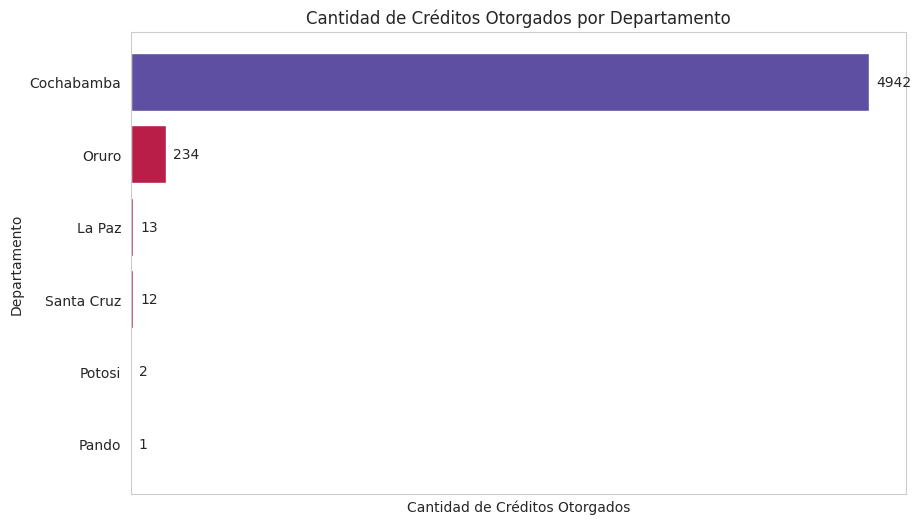

In [15]:
creditos_por_departamento = df_default.groupby('departamento')['id_credito'].count().sort_values()

# Normalizar los valores
norm = plt.Normalize(vmin=creditos_por_departamento.min(), vmax=creditos_por_departamento.max())
colors = cm.Spectral(norm(creditos_por_departamento.values))

# Barplot de la cantidad de creditos otorgados por departamento
plt.figure(figsize=(10, 6))
plt.barh(creditos_por_departamento.index, creditos_por_departamento.values, color=colors)
plt.ylabel("Departamento")
plt.xlabel("Cantidad de Créditos Otorgados")
plt.title("Cantidad de Créditos Otorgados por Departamento")

# Data labels en cada barra
for i, h in enumerate(creditos_por_departamento.values):
    plt.text(h+50, i, str(h), ha='left', va='center')

# Quitar grid y numeros del eje
plt.grid(False)
plt.xticks([])
plt.show()

Cómo se puede ver, alrededor del 95% de los créditos otorgados son de Cochabamba, por lo que se procederá a filtrar el conjunto de datos para los clientes de este departamento.

Finalmente se eliminará la variable departamento, porque ahora es redundante.

In [16]:
df_default = df_default.loc[df_default['departamento'] == 'Cochabamba']
df_default.drop('departamento', axis=1, inplace=True)

<ipython-input-16-bbdca1648562>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_default.drop('departamento', axis=1, inplace=True)


Se realizará el análisis de forma separada para las variables que describen directamente al crédito, las que describen a los clientes, y otras que se considerarán como generales o especiales.

**Variables de Cliente:**

*   Numéricas: numero_creditos, ingresos_anual, gastos_anual, antiguedad_actividad, edad
*   Categóricas: genero, estado_civil, actividad_economica

**Variables de Crédito:**

*   Numéricas: tasa_interes, cuotas_pactadas, duracion_credito, periodo_pago_interes, monto_desembolso, saldo_credito, monto_diferido_bs, interes_diferido_bs, dias_mora, monto_garantia_bs, monto_favor_bs
*   Categóricas: forma_pago, periodo_amortizacion, estado, tipo_credito, destino_credito

**Variables Especiales / Generales:**

*   Categóricas: departamento
*   Fechas: fecha_desembolso, fecha_vencimiento

Para facilitar el trabajo se crearon dos funciones que ayuden a graficar tanto el histograma como el boxplot de cada variable numérica, mientras que para las variables categóricas se graficarán countplots

In [17]:
def analiza_vars_numerica(df, var_list, bins=40):
    """
    Genera histogramas y boxplots para cada variable numérica en var_list,
    usando diferentes paletas de Seaborn para cada variable.
    """
    # Paletas de Seaborn que iremos rotando
    palettes = ['Blues', 'Greens', 'Reds', 'Purples', 'Oranges', 'YlGnBu']

    total_vars = len(var_list)
    fig, axes = plt.subplots(nrows=total_vars, ncols=2, figsize=(10, 3*total_vars))

    for i, col in enumerate(var_list):
        # Selecciona la paleta según la posición i
        palette_name = palettes[i % len(palettes)]
        # Obtenemos 2 colores de esa paleta (uno para histograma y otro para boxplot)
        color_list = sns.color_palette(palette_name, n_colors=2)
        hist_color = color_list[0]
        box_color = color_list[1]

        # Histograma con KDE
        sns.histplot(data=df, x=col, kde=True, bins=bins, ax=axes[i,0], color=hist_color)
        axes[i,0].set_title(f"Histograma de {col}", fontsize=12)

        # Boxplot
        sns.boxplot(data=df, x=col, ax=axes[i,1], color=box_color)
        axes[i,1].set_title(f"Boxplot de {col}", fontsize=12)

    plt.tight_layout()
    plt.show()

In [18]:
def analiza_vars_categorica(df, var_list):
    """
    Grafica la frecuencia (conteo de id_credito) por cada categoría en var_list,
    usando diferentes paletas para cada variable, con barras horizontales.
    """
    palettes = ['Blues', 'Greens', 'Reds', 'Purples', 'Oranges', 'YlGnBu']

    total_vars = len(var_list)
    nrows = math.ceil(total_vars/2)  # 2 gráficos por fila
    fig, axes = plt.subplots(nrows=nrows, ncols=2, figsize=(10, 3*nrows))
    axes = axes.flatten()  # Para indexar fácilmente

    for i, col in enumerate(var_list):
        freq_data = df.groupby(col)['id_credito'].count().sort_values(ascending=True)

        # Selecciona la paleta
        palette_name = palettes[i % len(palettes)]
        # Tomamos un color del medio, por ejemplo
        color_list = sns.color_palette(palette_name, n_colors=5)
        bar_color = color_list[2]

        # Graficar en barras horizontales: barh(y=índice, x=valores)
        axes[i].barh(freq_data.index.astype(str), freq_data.values, color=bar_color)
        axes[i].set_title(f"Conteo de id_credito por {col}", fontsize=12)

    # Ocultar ejes sobrantes si hay un número impar de variables
    if total_vars < len(axes):
        for j in range(total_vars, len(axes)):
            axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

In [19]:
# Variables de Cliente
cliente_num = ['numero_creditos', 'ingresos_anual', 'gastos_anual', 'antiguedad_actividad', 'edad']
cliente_cat = ['genero', 'estado_civil', 'actividad_economica']

# Variables de Crédito
credito_num = ['tasa_interes', 'cuotas_pactadas', 'duracion_credito', 'periodo_pago_interes',
               'monto_desembolso', 'saldo_credito', 'monto_diferido_bs', 'interes_diferido_bs',
               'dias_mora', 'monto_garantia_bs', 'monto_favor_bs']
credito_cat = ['forma_pago', 'periodo_amortizacion', 'estado', 'tipo_credito', 'destino_credito']

# Variables Especiales / Generales
especial_cat = ['departamento']
fechas = ['fecha_desembolso', 'fecha_vencimiento']

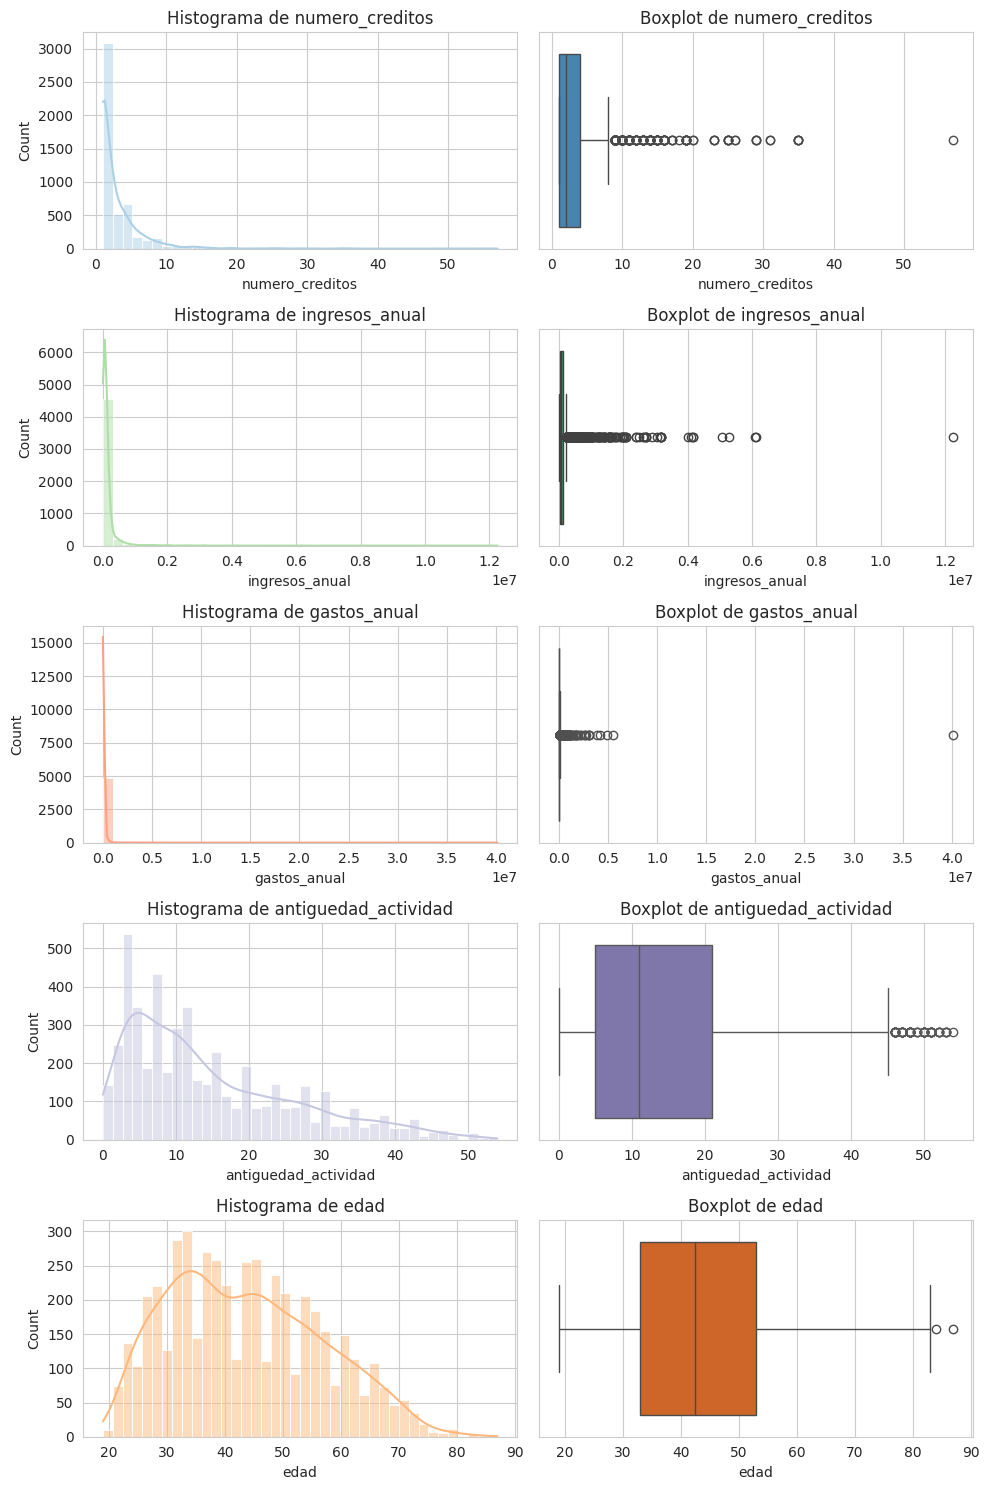

In [20]:
analiza_vars_numerica(df_default, cliente_num)

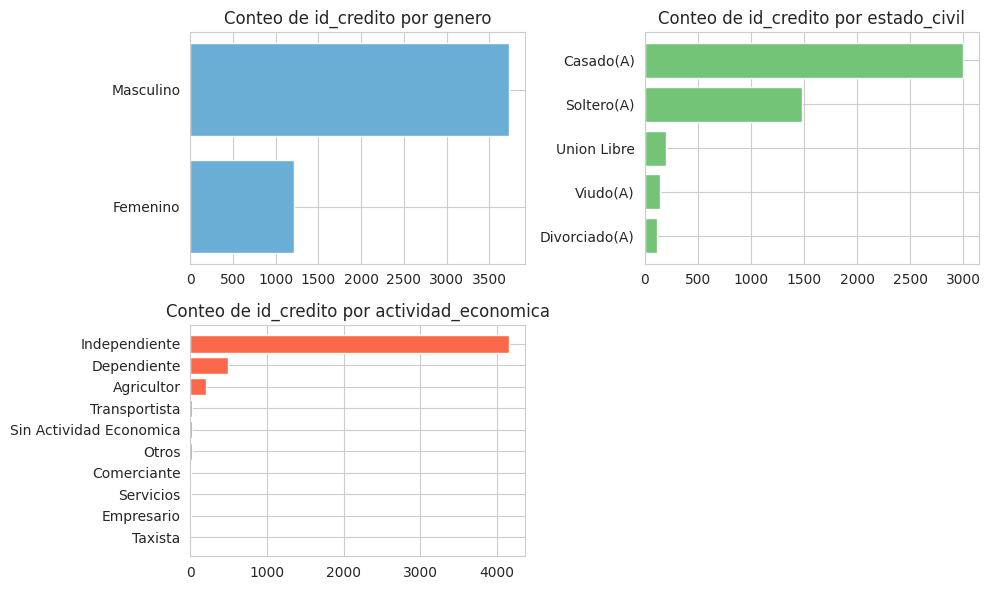

In [21]:
analiza_vars_categorica(df_default, cliente_cat)

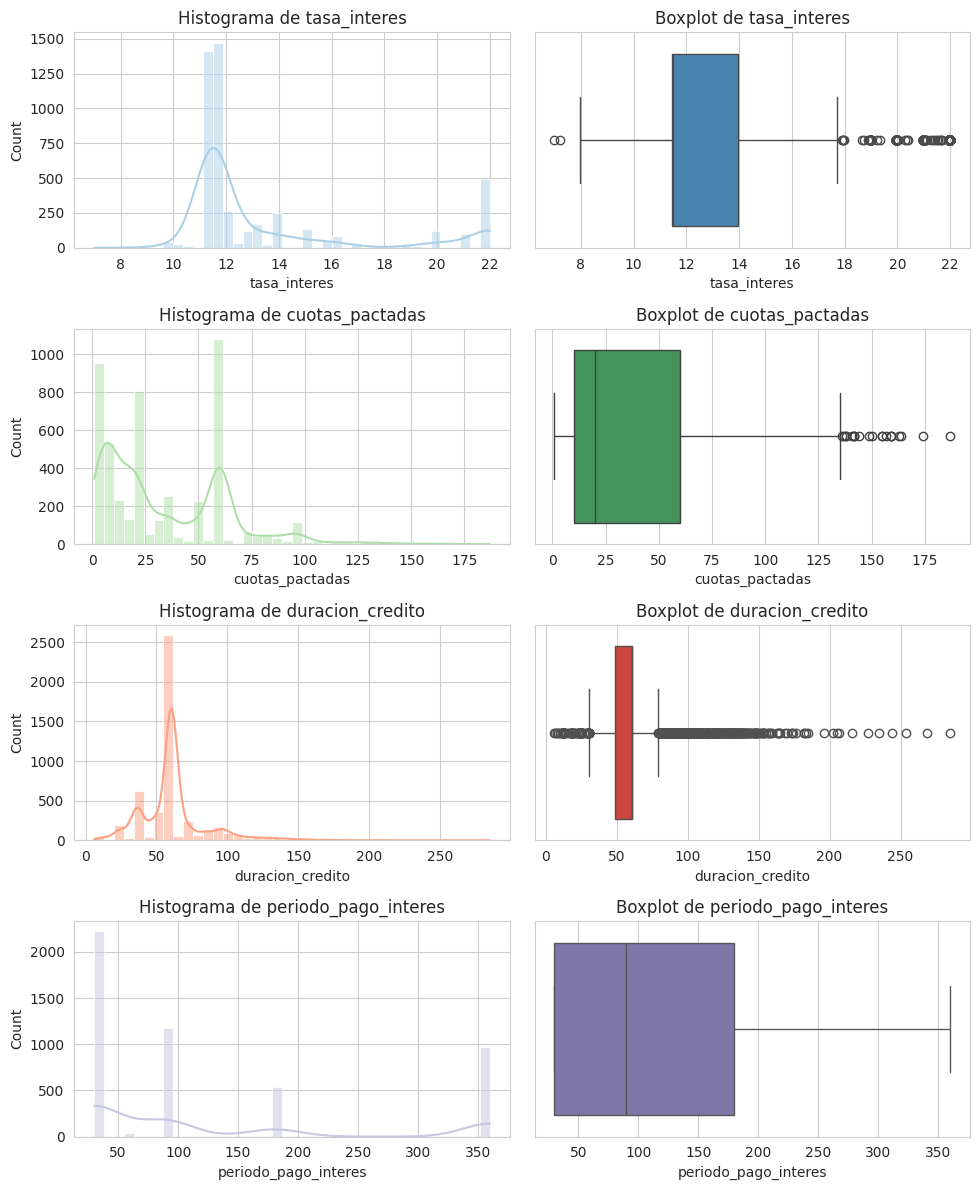

In [22]:
analiza_vars_numerica(df_default, credito_num[:4])

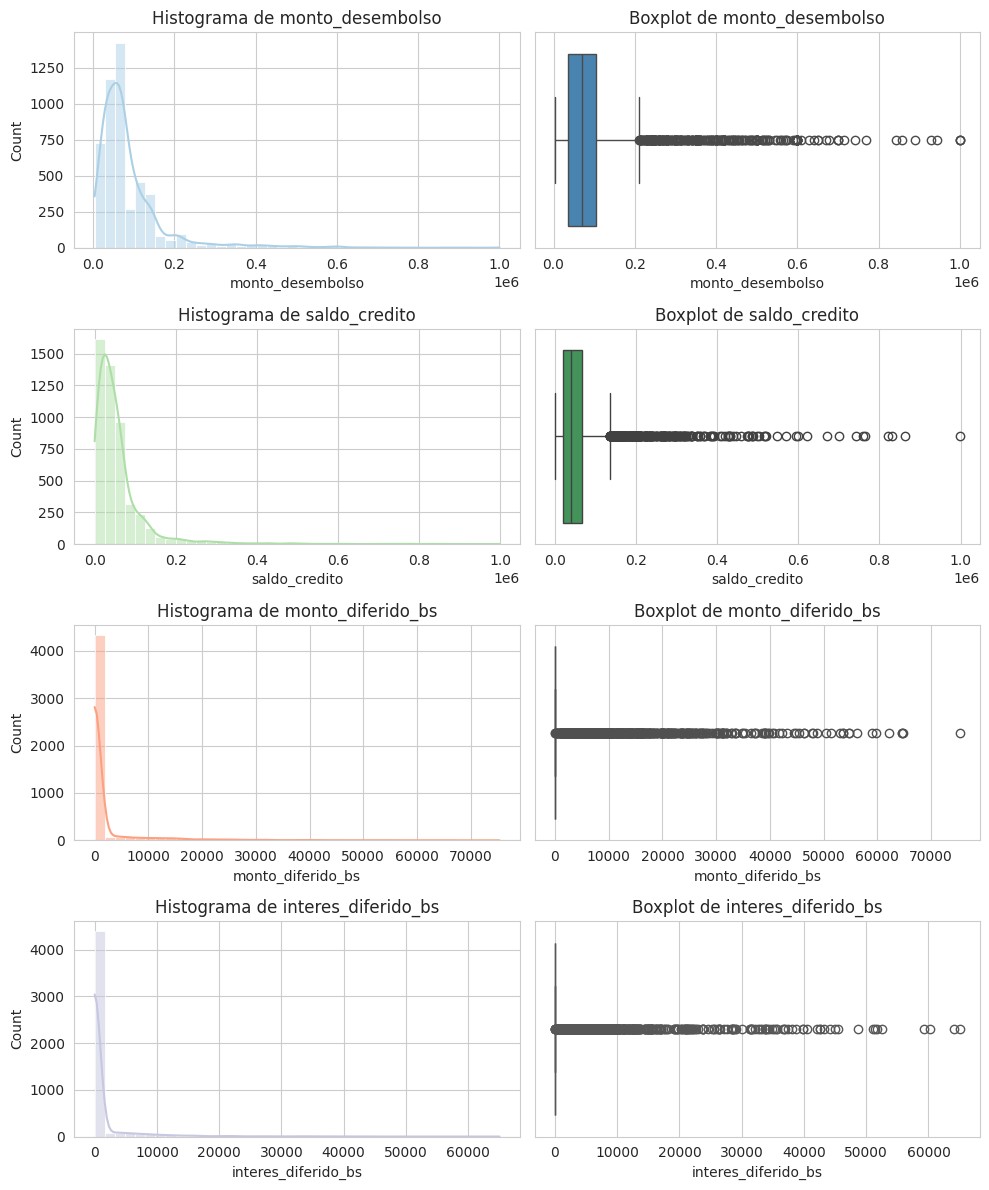

In [23]:
analiza_vars_numerica(df_default, credito_num[4:8])

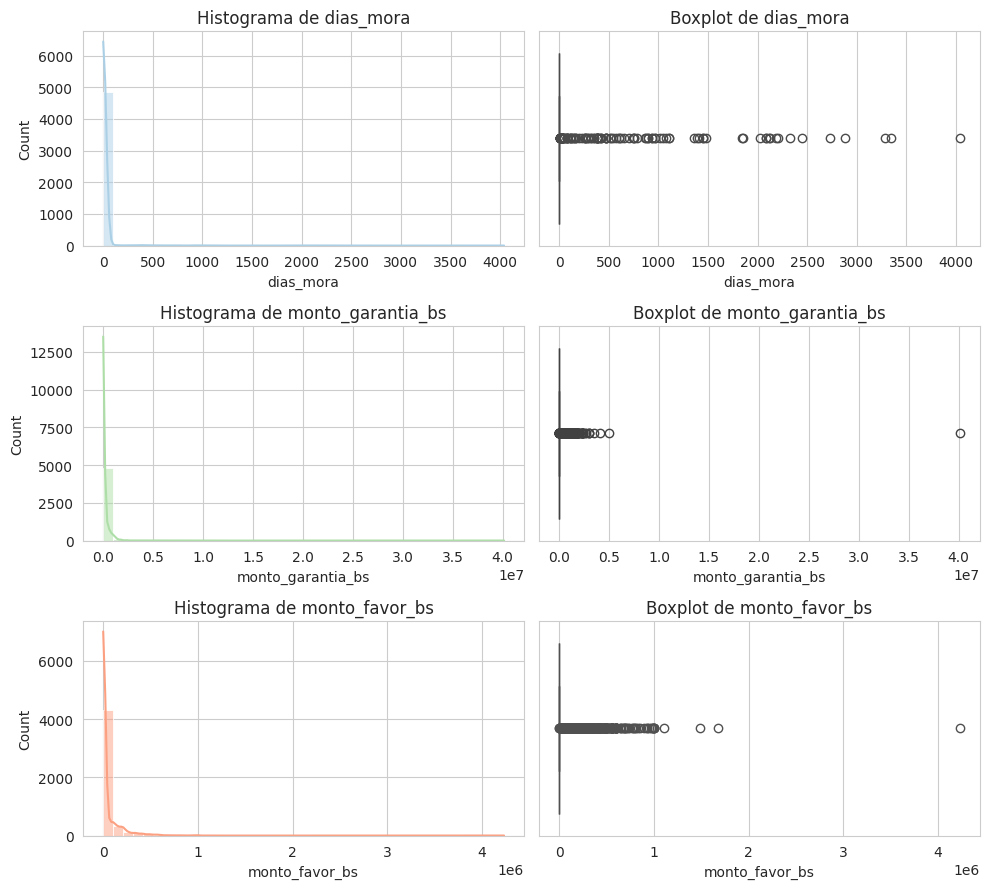

In [24]:
analiza_vars_numerica(df_default, credito_num[8:])

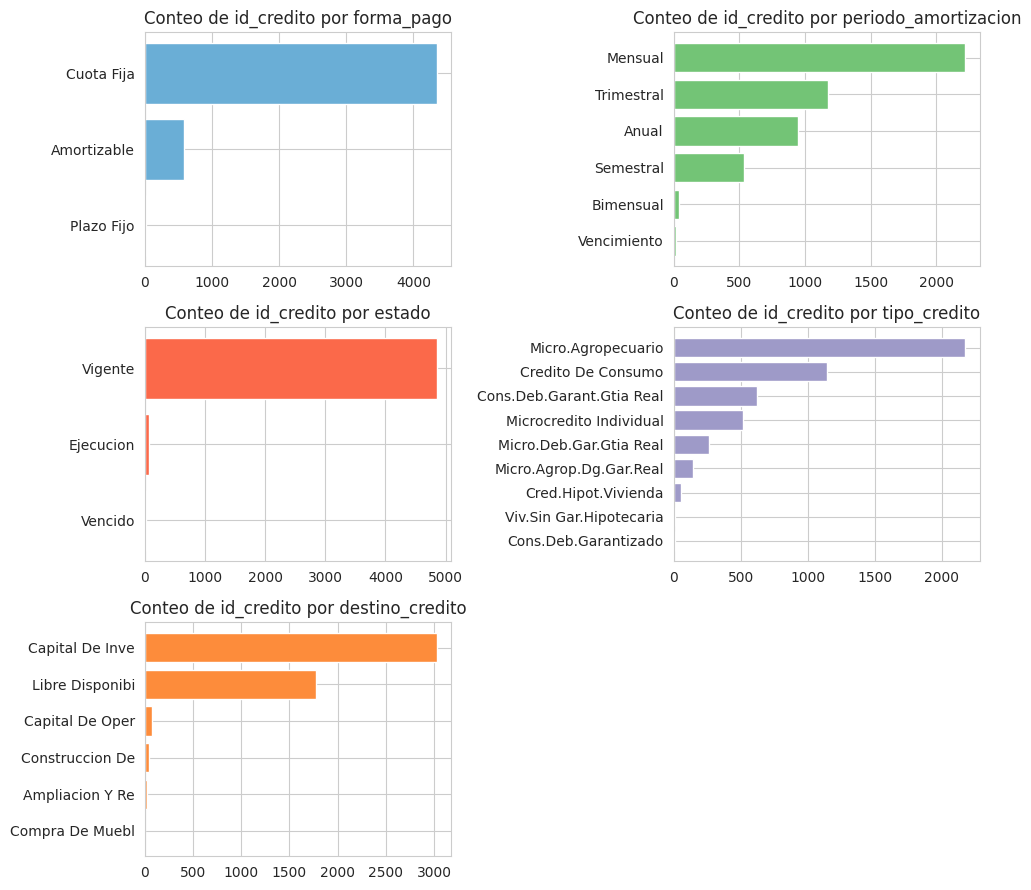

In [25]:
analiza_vars_categorica(df_default, credito_cat)

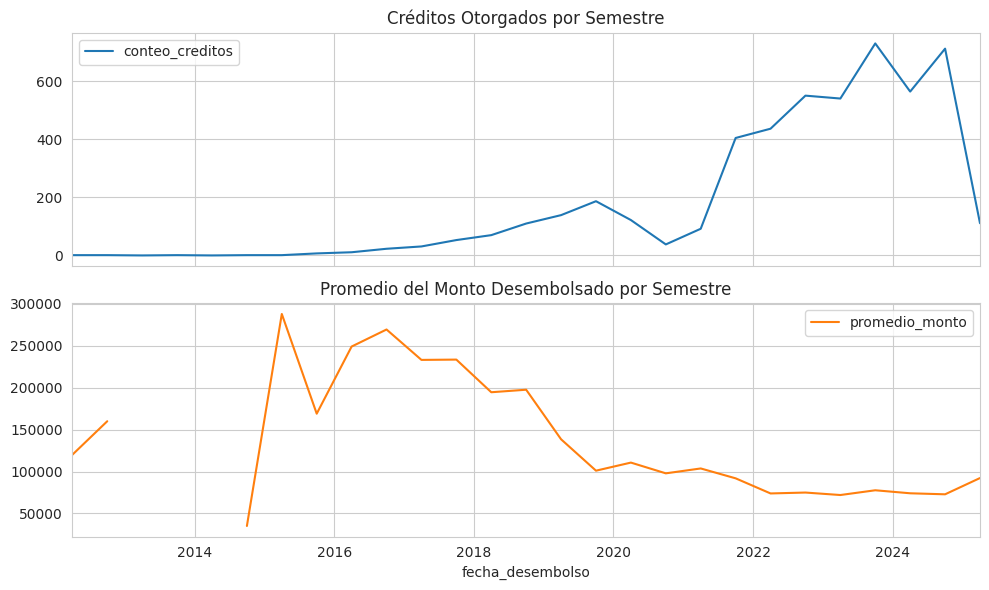

In [26]:
# Copia o reordena el DF para no perder otras columnas
df_time = df_default.copy()

# Establecer fecha_desembolso como índice
df_time.set_index('fecha_desembolso', inplace=True)

# Resample (agrupación) mensual:
df_resampled = df_time.resample('2QE').agg({
    'id_credito': 'count',         # Conteo de créditos
    'monto_desembolso': 'mean'      # promedio de montos desembolsados
})

df_resampled.rename(columns={'id_credito': 'conteo_creditos',
                             'monto_desembolso': 'promedio_monto'}, inplace=True)

# Graficar las dos series en subplots
df_resampled[['conteo_creditos','promedio_monto']].plot(
    subplots=True, figsize=(10,6),
    title=['Créditos Otorgados por Semestre','Promedio del Monto Desembolsado por Semestre']
)
plt.tight_layout()
plt.show()

# Análisis Bivariado

In [27]:
def analiza_num_bivariado(df, var_list, target='default'):
    """
    Genera, en una sola figura, un histograma (con hue=target) y un boxplot
    (x=target, y=variable) para cada variable numérica en var_list.
    Se organizan en 2 columnas fijas, y tantas filas como se requiera.
    """
    n = len(var_list)
    # 2 subplots por variable => total_subplots = 2 * n
    total_subplots = 2 * n

    # Paletas que rotaremos para el boxplot
    palettes = ['Accent', 'Paired', 'Pastel1', 'Set2', 'Set3', 'tab10', 'tab20']

    # 2 columnas => calculamos cuántas filas
    nrows = math.ceil(total_subplots / 2)

    fig, axes = plt.subplots(nrows, 2, figsize=(10, 4*nrows))
    axes = axes.flatten()  # Array 1D de ejes

    idx = 0
    for col in var_list:
        # Boxplot
        if idx < total_subplots:
            palette_name = palettes[i % len(palettes)]  # Ciclo de paletas
            # Obtenemos 2-3 colores de esa paleta y elegimos uno
            color_list = sns.color_palette(palette_name, n_colors=nrows)
            box_color = color_list[idx]

            sns.boxplot(data=df, x=target, y=col, ax=axes[idx], color=box_color)
            axes[idx].set_title(f"Boxplot: {col} vs. {target}")
            idx += 1

    # Ocultar ejes sobrantes (si sobran)
    for j in range(idx, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

In [28]:
def analiza_cat_bivariado(df, cat_list, target='default'):
    """
    Genera un 100% stacked bar horizontal para cada variable categórica en cat_list.
    Cada gráfico aparece en un subplot, organizados en una rejilla de 2 columnas.
    Usa paletas discretas y un ListedColormap para que cada clase del target tenga
    un color distintivo y bien visible.
    """
    n = len(cat_list)
    # Definimos 2 columnas; calculamos cuántas filas necesitamos
    nrows = math.ceil(n / 2)
    # Creamos la figura y ejes
    fig, axes = plt.subplots(nrows, 2, figsize=(12, 4*nrows))
    axes = axes.flatten()  # Convertimos en array 1D para indexar
    # Algunas paletas discretas de Seaborn/Matplotlib
    discrete_palettes = ['Accent', 'Paired', 'Pastel1', 'Set2', 'Set3', 'tab10', 'tab20']
    for i, cat_var in enumerate(cat_list):
        # Tabla de contingencia
        crosstab = pd.crosstab(df[cat_var], df[target])
        # Convertir a porcentaje (cada fila suma 100%)
        crosstab_perc = crosstab.div(crosstab.sum(axis=1), axis=0) * 100
        # Elegir la paleta de forma cíclica
        palette_name = discrete_palettes[i % len(discrete_palettes)]
        # Cantidad de clases en la variable objetivo
        n_classes = crosstab_perc.shape[1]
        # Creamos una lista de colores
        colors = sns.color_palette(palette_name, n_colors=n_classes)
        # Construimos un ListedColormap con esos colores
        cmap = ListedColormap(colors)
        # Graficar el stacked bar horizontal
        crosstab_perc.plot.barh(
            stacked=True,
            ax=axes[i],
            cmap=cmap
        )
        axes[i].set_xlabel("Porcentaje")
        axes[i].set_ylabel(cat_var)
        axes[i].set_title(f"Distribución de {target} por {cat_var}")
        axes[i].legend(title=target, bbox_to_anchor=(1.05, 1), loc='upper left')
    # Ocultamos subplots sobrantes si n es impar
    if n < len(axes):
        for j in range(n, len(axes)):
            axes[j].set_visible(False)
    plt.tight_layout()
    plt.show()

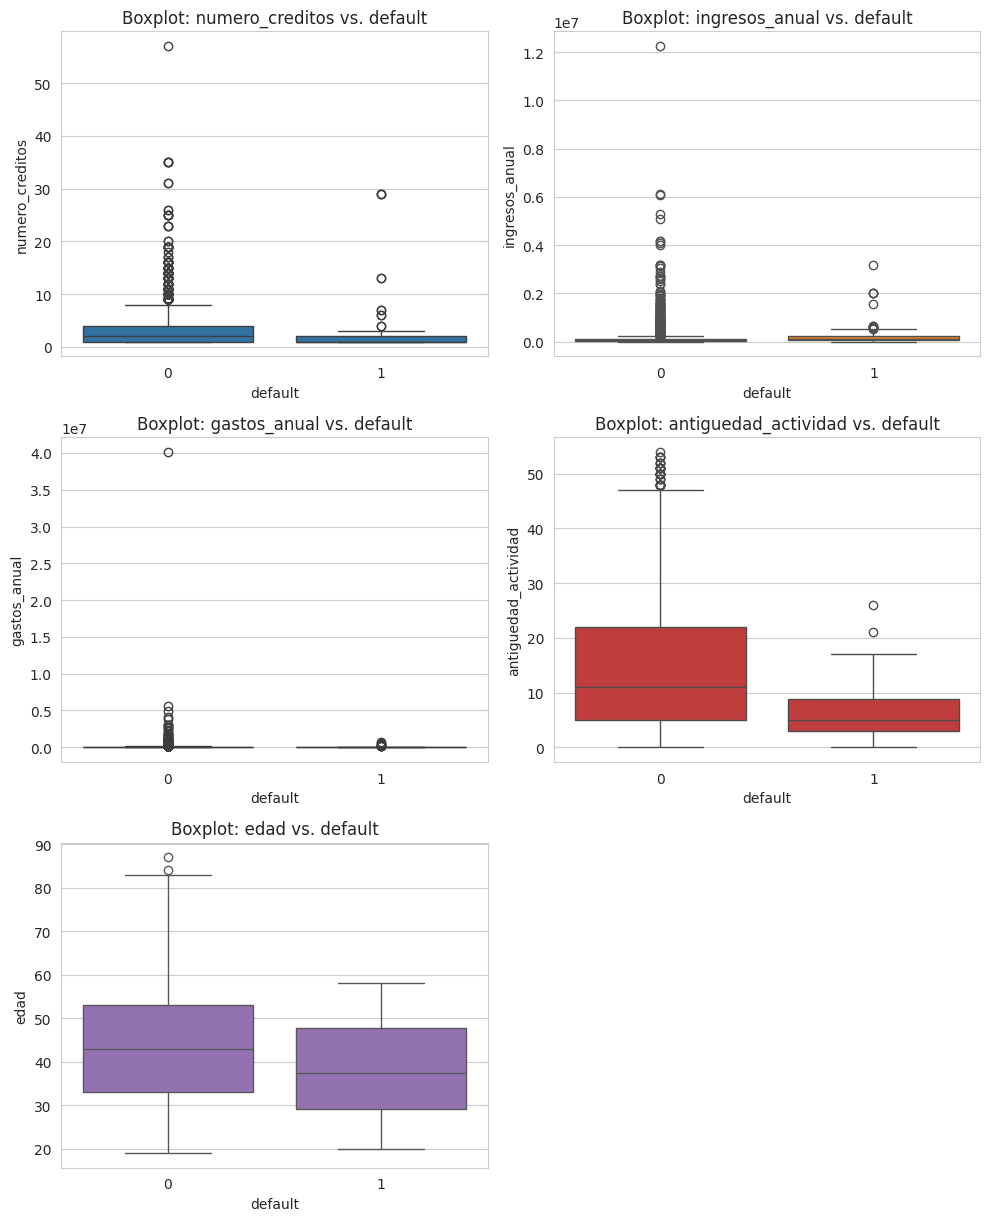

In [29]:
analiza_num_bivariado(df_default, cliente_num)

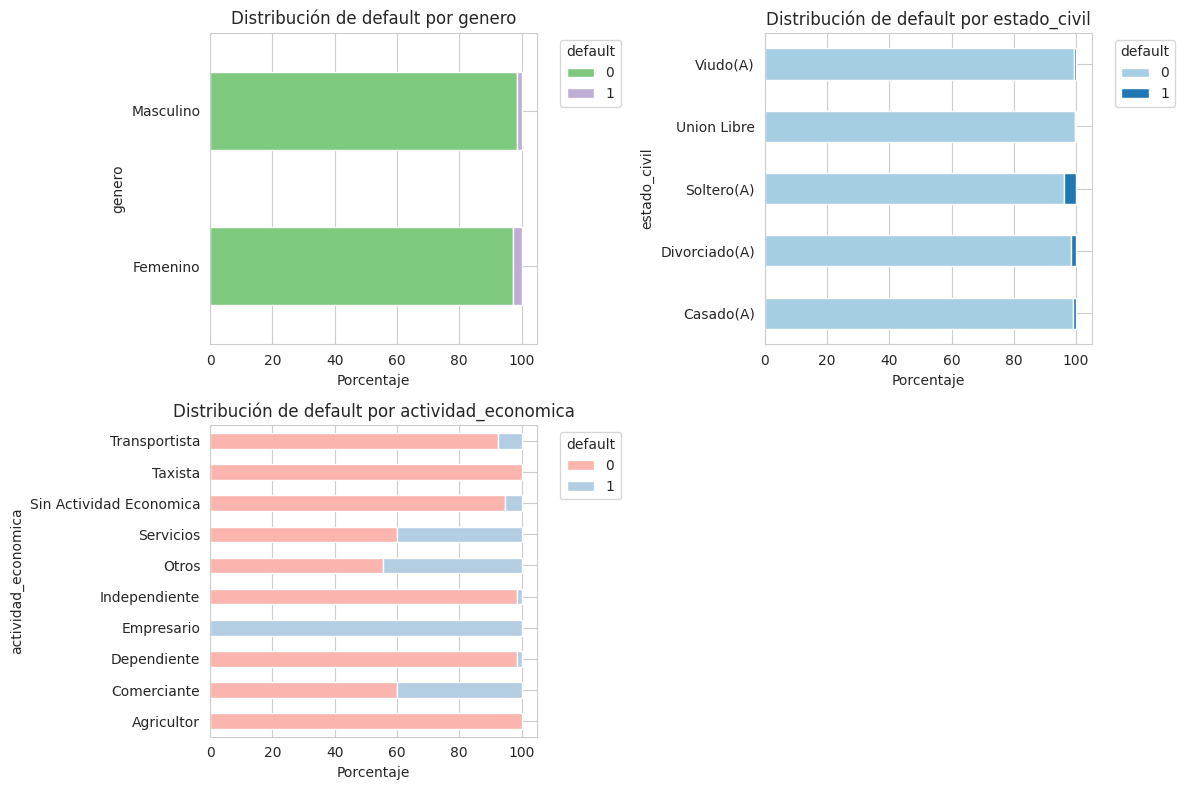

In [30]:
analiza_cat_bivariado(df_default, cliente_cat)

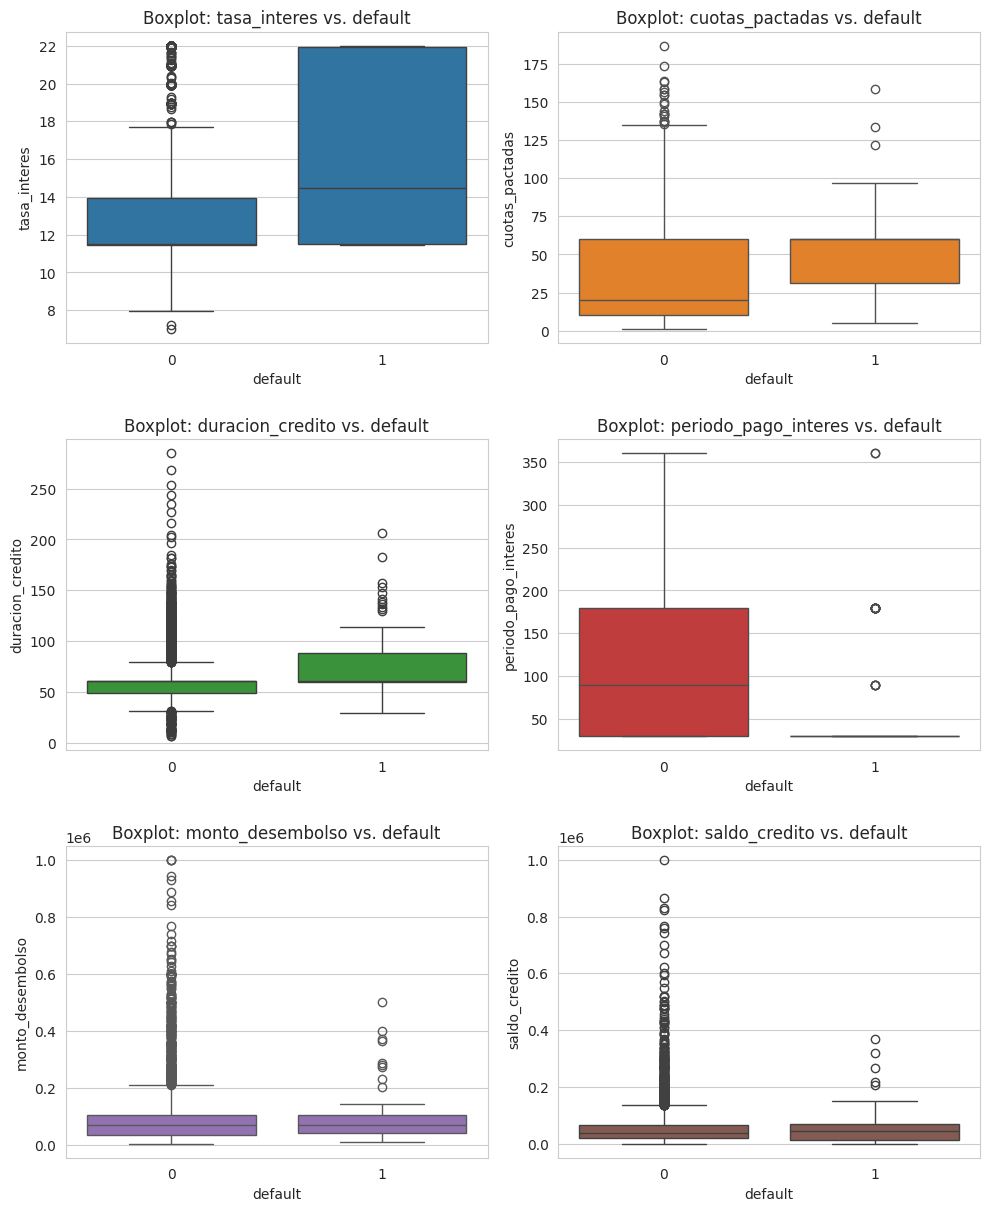

In [31]:
analiza_num_bivariado(df_default, credito_num[:6])

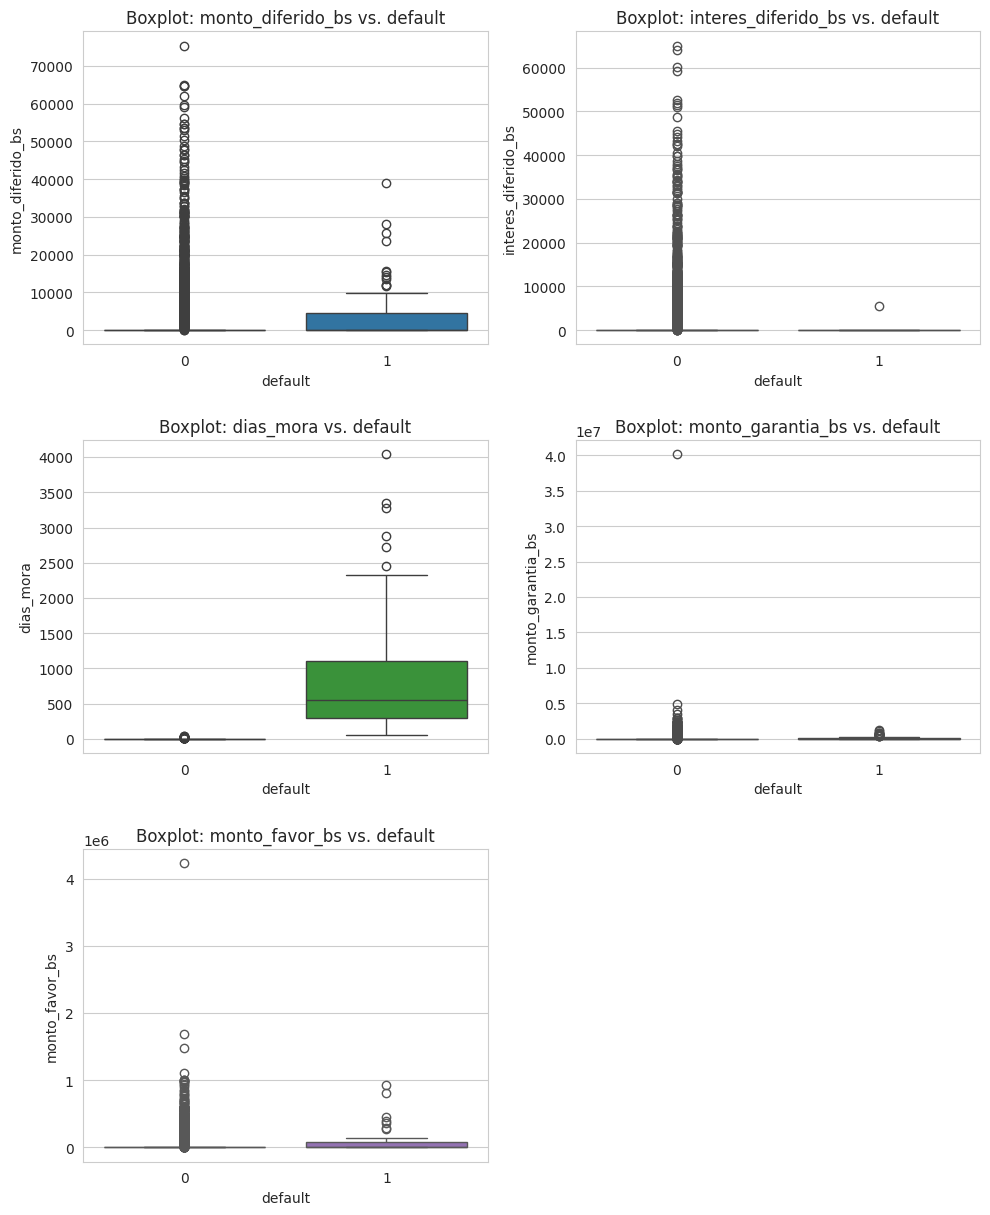

In [32]:
analiza_num_bivariado(df_default, credito_num[6:])

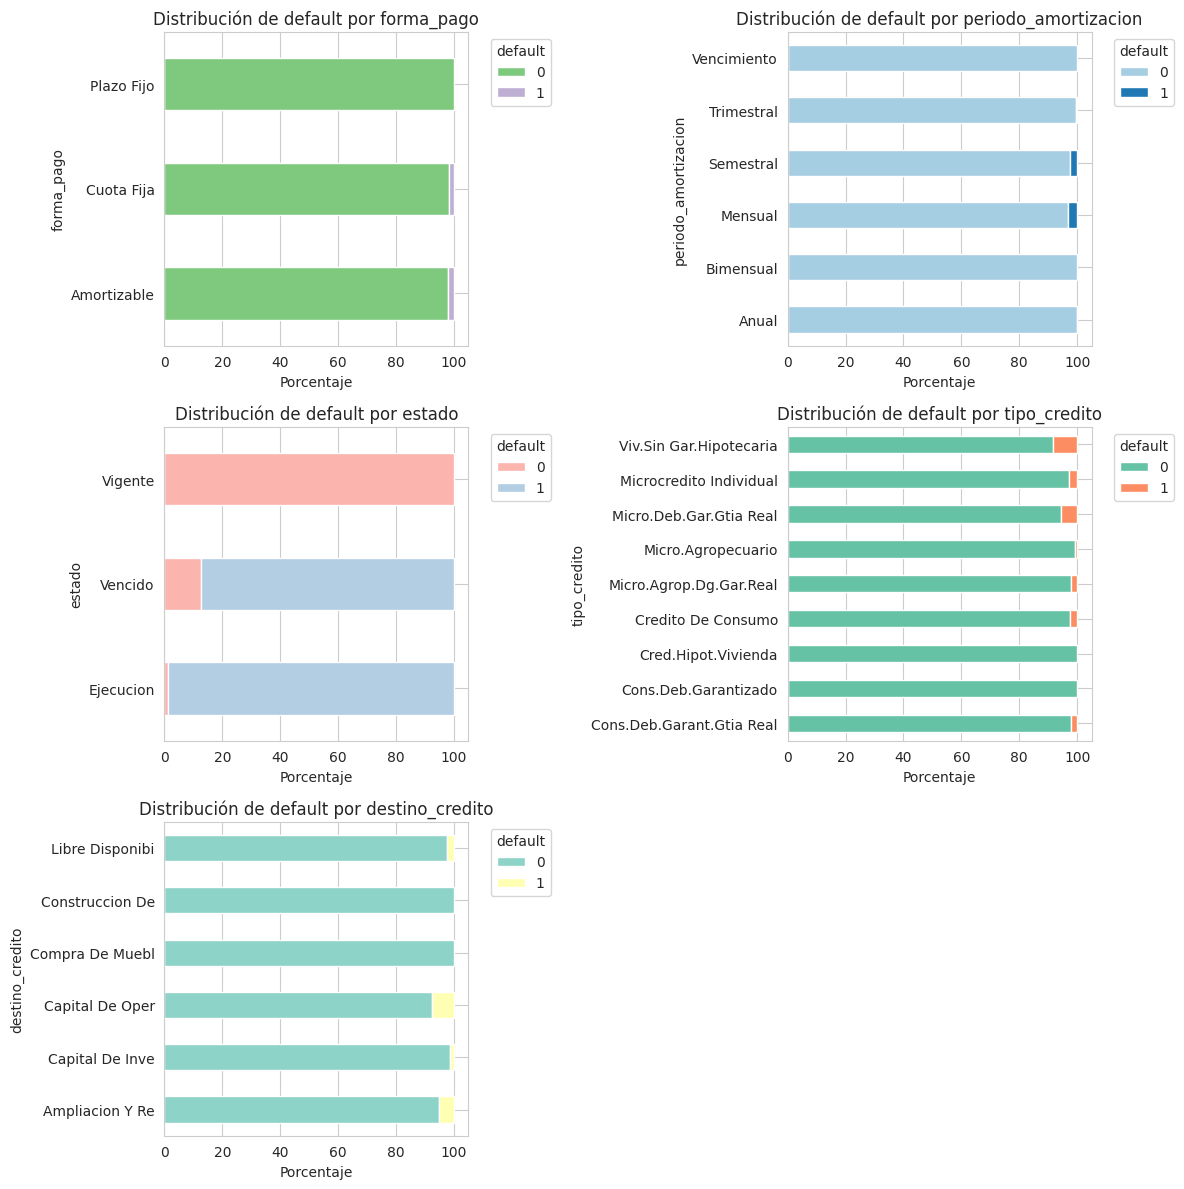

In [33]:
analiza_cat_bivariado(df_default, credito_cat)

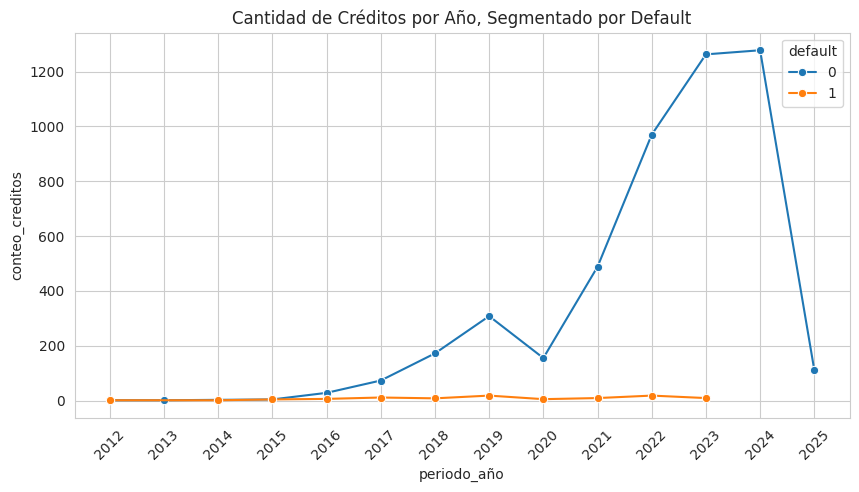

In [34]:
df_time = df_default.copy()

df_time['periodo_año'] = df_time['fecha_desembolso'].dt.to_period('Y').astype(str)

df_grouped_def = df_time.groupby(['periodo_año','default']).agg({
    'id_credito': 'count',
    'monto_desembolso': 'mean'
}).reset_index()

df_grouped_def.rename(columns={'id_credito': 'conteo_creditos',
                               'monto_desembolso': 'prom_monto'}, inplace=True)

plt.figure(figsize=(10,5))
sns.lineplot(data=df_grouped_def,
             x='periodo_año',
             y='conteo_creditos',
             hue='default',
             marker='o')
plt.xticks(rotation=45)
plt.title("Cantidad de Créditos por Año, Segmentado por Default")
plt.show()

# Correlación de Variables Numéricas

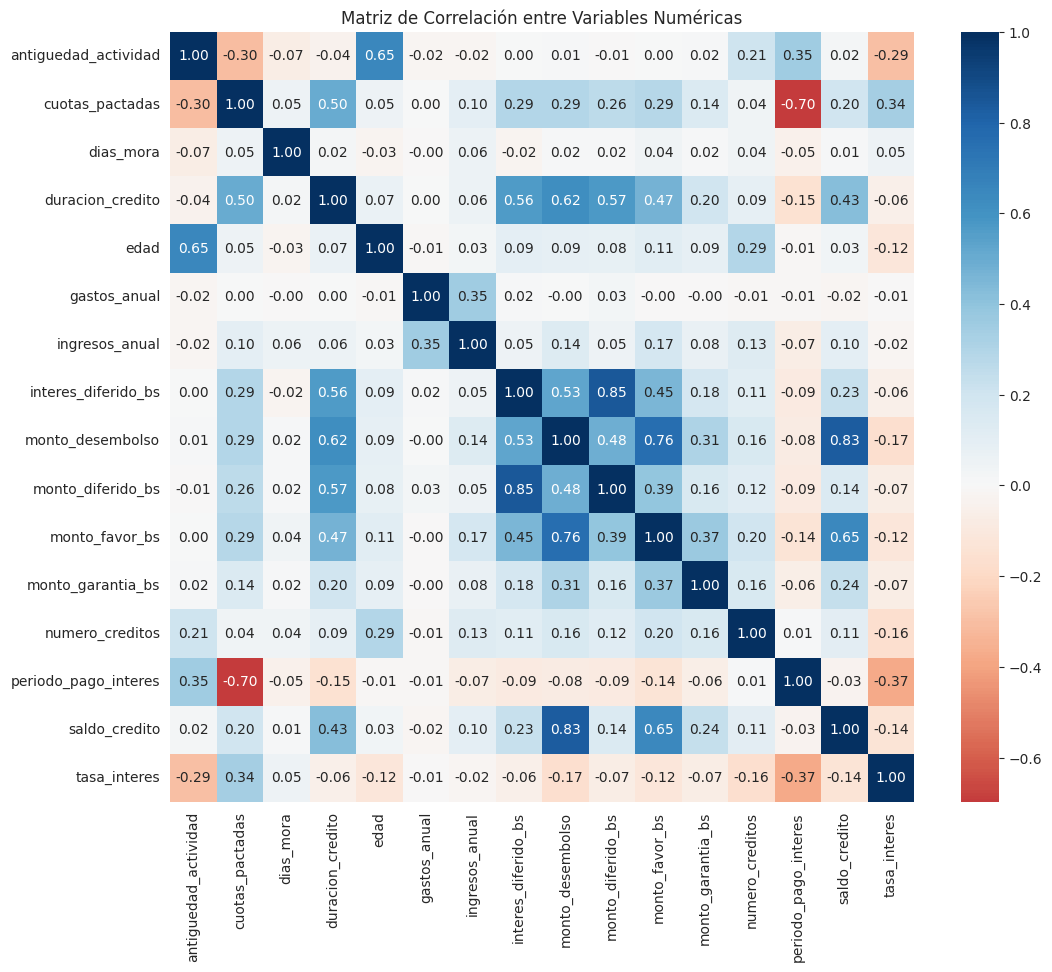

In [35]:
columnas_numericas = df_default.select_dtypes(include=['number']).drop('default', axis=1).columns.sort_values()
# Definir el DF de variables numericas para el Calculo
df_num = df_default[columnas_numericas]

# Calcular la matriz de correlación Pearson
corr_matrix = df_num.corr()

# Graficar el heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu", center=0)
plt.title("Matriz de Correlación entre Variables Numéricas")
plt.show()

# Asociación entre Variables Categóricas

In [36]:
def cramers_v(x, y):
    """
    Calcula Cramér's V para medir la asociación entre dos variables categóricas.
    """
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

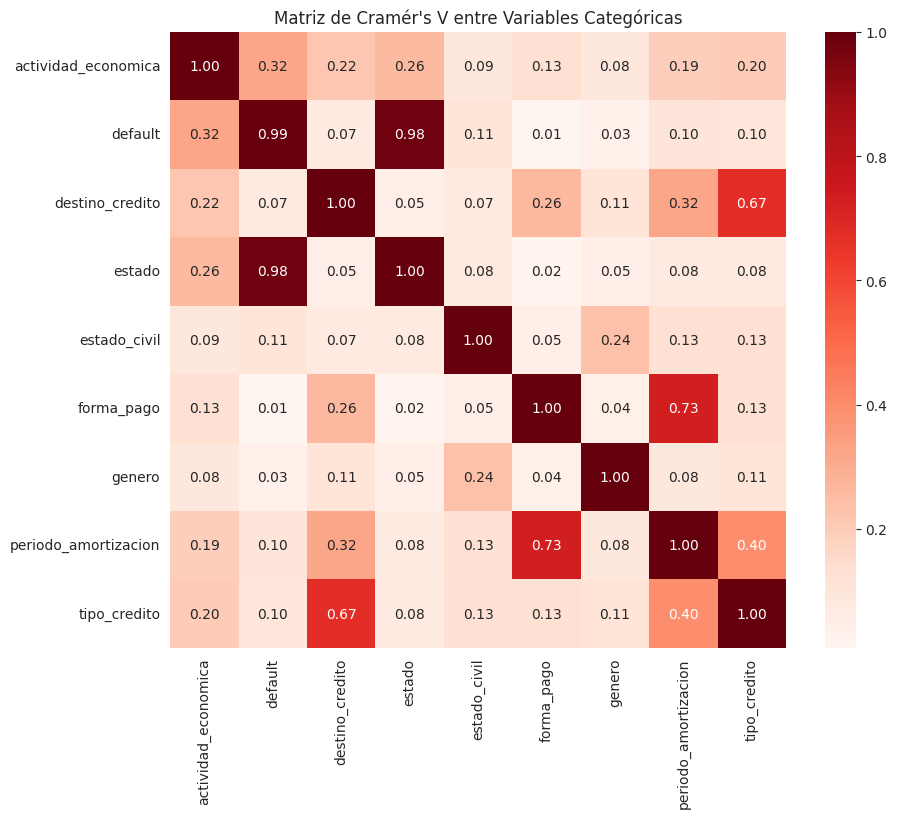

In [37]:
# convierte en tipo object al campo default
df_default['default'] = df_default['default'].astype('object')

# Tomamos todas las columnas de tipo object, sin contar Identificadores
cat_cols = df_default.select_dtypes(include=['object']).drop(['id_credito', 'id_agencia', 'id_socio'], axis=1).columns.sort_values()

matrix_size = len(cat_cols)
cramers_results = pd.DataFrame(np.zeros((matrix_size, matrix_size)),
                               index=cat_cols, columns=cat_cols)

for i in range(matrix_size):
    for j in range(i, matrix_size):
        v = cramers_v(df_default[cat_cols[i]], df_default[cat_cols[j]])
        cramers_results.iloc[i,j] = v
        cramers_results.iloc[j,i] = v  # simétrico

# Heatmap de Cramér's V
plt.figure(figsize=(10,8))
sns.heatmap(cramers_results, annot=True, fmt=".2f", cmap="Reds", square=True)
plt.title("Matriz de Cramér's V entre Variables Categóricas")
plt.show()

In [38]:
df_default.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4942 entries, 1 to 5246
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id_credito            4942 non-null   object        
 1   id_socio              4942 non-null   object        
 2   fecha_desembolso      4942 non-null   datetime64[ns]
 3   fecha_vencimiento     4942 non-null   datetime64[ns]
 4   tasa_interes          4942 non-null   float64       
 5   forma_pago            4942 non-null   object        
 6   periodo_amortizacion  4942 non-null   object        
 7   cuotas_pactadas       4942 non-null   int64         
 8   periodo_pago_interes  4942 non-null   int64         
 9   monto_desembolso      4942 non-null   float64       
 10  saldo_credito         4942 non-null   float64       
 11  monto_diferido_bs     4942 non-null   float64       
 12  interes_diferido_bs   4942 non-null   float64       
 13  dias_mora             4

# Preparación de los Datos
En esta sección se decidirá columnas a eliminar, se transformarán las variables númericas y categoricas con el fin de obtener una tabla minable que pueda ser alimentada a los modelos para su respectivo entrenamiento.

In [39]:
# Importar librerias para preprocesamiento de datos y creación de pipelines
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer

## Eliminación de variables
Se eliminarán la fecha de vencimiento, fecha de desembolso, identificadores, el estado y los días de mora de los créditos. Debido a que son variables redundantes que repiten información al modelo o que no aportan lo necesario.

In [40]:
# regresa el campo default a su tipo de dato original
df_default['default'] = df_default['default'].astype('int64')

df_default = df_default.drop(['fecha_vencimiento', 'fecha_desembolso', 'id_agencia', 'id_socio', 'id_credito', 'estado', 'dias_mora'], axis=1)

## Agrupación de variables categóricas

Dado que hay muchas clases en las variables categóricas que no tienen una cantidad representativa, se tiene la idea de agruparlas en clases más generales de modo que se reduzca el número de columnas generadas en el One-Hot Encoding y se tengan clases más representativas.

In [41]:
# Estado Civil
map_estado_civil = {
    'Casado(A)': 'Casado',
    'Soltero(A)': 'Soltero',
    'Union Libre': 'Otros',
    'Viudo(A)': 'Otros',
    'Divorciado(A)': 'Otros'
}
df_default['estado_civil'] = df_default['estado_civil'].map(map_estado_civil).fillna('Otros')

# Actividad Económica
map_actividad_economica = {
    'Dependiente': 'Dependiente',
    'Independiente': 'Independiente',
    'Agricultor': 'Independiente',
    'Transportista': 'Independiente',
    'Taxista': 'Independiente',
    'Empresario': 'Independiente',
    'Comercio': 'Independiente',
    'Servicios': 'Independiente',
    'Sin Actividad Economica': 'SinActividad'
}
df_default['actividad_economica'] = df_default['actividad_economica'].map(map_actividad_economica).fillna('Otros')

# Periodo Amortizacion
map_periodo_amort = {
    'Mensual': 'Mensual',
    'Trimestral': 'Trimestral',
    'Anual': 'Anual',
    'Semestral': 'Semestral',
    'Bimensual': 'Otros',
    'Vencimiento': 'Otros'
}

df_default['periodo_amortizacion'] = df_default['periodo_amortizacion'].map(map_periodo_amort).fillna('Otros')

# Tipo de Credito
map_tipo_credito = {
    'Micro.Agropecuario': 'Microcredito',
    'Microcredito Individual': 'Microcredito',
    'Micro.Agrop.Dg.Gar.Real': 'Microcredito',
    'Micro.Deb.Gar.Gtia Real': 'Microcredito',
    'Cons.Deb.Garant.Gtia Real': 'Consumo',
    'Credito De Consumo': 'Consumo',
    'Cons.Deb.Garantizado': 'Consumo',
    'Viv.Sin Gar.Hipotecaria': 'Vivienda',
    'Cred.Hipot.Vivienda': 'Vivienda'
    # El resto => 'Otros'
}

df_default['tipo_credito'] = df_default['tipo_credito'].map(map_tipo_credito).fillna('Otros')

# Destino de Credito
map_destino_credito = {
    'Capital De Inve': 'Capital',
    'Capital De Oper': 'Capital',
    'Construccion De': 'Inmueble',
    'Ampliacion Y Re': 'Inmueble',
    'Compra De Muebl': 'Libre Disponibilidad',
    'Libre Disponibi': 'Libre Disponibilidad'
    # Lo que no aparezca aquí => 'Otros'
}

df_default['destino_credito'] = df_default['destino_credito'].map(map_destino_credito).fillna('Otros')

## Imputación y Creación de Variables

In [42]:
numericas = df_default.select_dtypes(include=['number']).drop('default', axis=1).columns

df_default['ingresos_anual'] = df_default['ingresos_anual'].replace(0, np.nan)
df_default['gastos_anual'] = df_default['gastos_anual'].replace(0, np.nan)

imputer = SimpleImputer(strategy='median')
df_default[numericas] = imputer.fit_transform(df_default[numericas])

# pct_pagado
df_default['pct_pagado'] = 1 - (df_default['saldo_credito'] / df_default['monto_desembolso'])

# ratio_gastos_ingresos, manteniendo 0 si los ingresos son 0
df_default['ratio_gastos_ingresos'] = df_default['gastos_anual'] / df_default['ingresos_anual']

# total_diferido
df_default['total_diferido'] = df_default['monto_diferido_bs'] + df_default['interes_diferido_bs']

## Gráfica de Barras Horizontal del Sesgo de las Variables Numéricas

Se realiza el siguiente gráfico para determinar que variables tienen el sesgo más alto y ver si se beneficiarían de una transformación logarítmica.

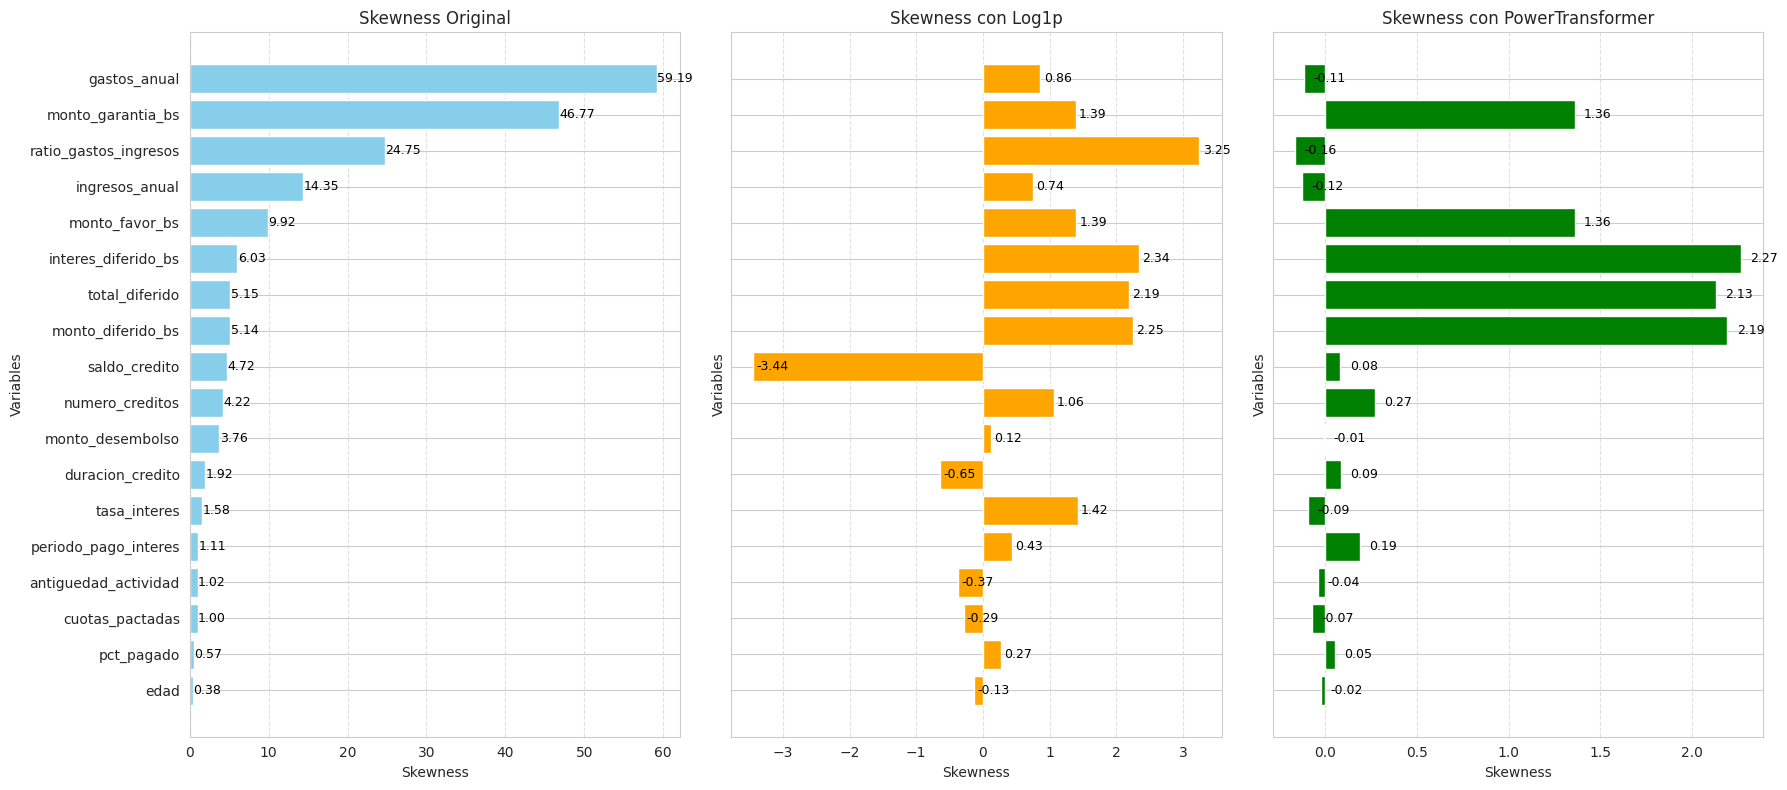

In [43]:
from sklearn.preprocessing import PowerTransformer, FunctionTransformer


def plot_skewness_comparison(df):
    """
    Genera un subplot con 3 gráficos de barras:
    1. Skewness original
    2. Skewness después de aplicar log1p
    3. Skewness después de aplicar PowerTransformer
    """
    # Seleccionar solo columnas numéricas (excluyendo 'default')
    numeric_cols = df.select_dtypes(include=[np.number]).drop('default', axis=1).columns

    # Calcular skewness original
    skew_original = df[numeric_cols].skew()

    # Aplicar log1p (log(1+x))
    df_log = df[numeric_cols].apply(np.log1p)
    skew_log = df_log.skew()

    # Aplicar PowerTransformer (yeo-johnson)
    power_transformer = PowerTransformer(method='yeo-johnson')
    df_power = pd.DataFrame(power_transformer.fit_transform(df[numeric_cols]), columns=numeric_cols)
    skew_power = df_power.skew()

    # Ordenar de mayor a menor skewness original
    sorted_idx = skew_original.sort_values(ascending=True).index

    # Crear figura con 3 subplots en 1 fila
    fig, axes = plt.subplots(1, 3, figsize=(18, 8), sharey=True)

    # Función auxiliar para graficar cada subplot
    def plot_bars(ax, skew_vals, title, color):
        ax.barh(sorted_idx, skew_vals[sorted_idx], color=color)
        ax.set_title(title)
        ax.set_xlabel("Skewness")
        ax.set_ylabel("Variables")
        ax.grid(axis='x', linestyle='--', alpha=0.6)

        # Agregar etiquetas de valores en las barras
        for i, v in enumerate(skew_vals[sorted_idx]):
            ax.text(v + 0.05, i, f"{v:.2f}", va='center', fontsize=9, color='black')

    # Graficar skewness original
    plot_bars(axes[0], skew_original, "Skewness Original", "skyblue")

    # Graficar skewness con log1p
    plot_bars(axes[1], skew_log, "Skewness con Log1p", "orange")

    # Graficar skewness con PowerTransformer
    plot_bars(axes[2], skew_power, "Skewness con PowerTransformer", "green")

    plt.tight_layout()
    plt.show()

# Ejecutar función con el DataFrame df_default
plot_skewness_comparison(df_default)

In [44]:
# agrupar columnas numéricas sesgadas
numericas_sesgada_total = df_default.select_dtypes(include=['number']).drop(
    ['default', 'edad', 'cuotas_pactadas', 'antiguedad_actividad', 'periodo_pago_interes', 'pct_pagado'],
    axis=1).columns

numericas_sesgada_sin_orig = df_default.select_dtypes(include=['number']).drop(
    ['default', 'edad', 'cuotas_pactadas', 'antiguedad_actividad', 'periodo_pago_interes', 'monto_diferido_bs',
     'interes_diferido_bs', 'pct_pagado', 'gastos_anual', 'ingresos_anual', 'saldo_credito', 'monto_desembolso'],
    axis=1).columns

# columnas numericas sin un sesgo pronunciado
numericas_no_sesgada = ['edad', 'cuotas_pactadas', 'antiguedad_actividad', 'periodo_pago_interes', 'pct_pagado']

# agrupar columnas categoricas basado en el tipo de datos
categoricas = df_default.select_dtypes(include=['object']).columns

In [45]:
from sklearn.preprocessing import FunctionTransformer, PowerTransformer

# PowerTransformer pipeline

pipeline_power = Pipeline([
    ('power', PowerTransformer(method='yeo-johnson'))
])

# Transformación log1p
log_transformer = FunctionTransformer(np.log1p, validate=False)

# Pipeline numérico imputar -> feat_engineer -> log -> standard o robust
pipeline_num_log = Pipeline([
    ('log', log_transformer)
])

pipeline_num_log_std = Pipeline([
    ('log', log_transformer),
    ('scaler', StandardScaler())
])

pipeline_num_log_robust = Pipeline([
    ('log', log_transformer),
    ('scaler', RobustScaler())
])

#Pipeline para variables no sesgadas
pipeline_num_no_log_std = Pipeline([
    ('scaler', StandardScaler())
])

In [46]:
# Pipeline para variables categoricas
pipeline_cat = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='faltante')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [47]:
# Column Transformers

# Quitando originales Power
ct_power_drop = ColumnTransformer([
    ('num_sesgada', pipeline_power, numericas_sesgada_sin_orig),
    ('num_no_sesgada', pipeline_num_no_log_std, numericas_no_sesgada),
    ('cat', pipeline_cat, categoricas)
])

# Manteniendo originales Power
ct_power_keep = ColumnTransformer([
    ('num_sesgada', pipeline_power, numericas_sesgada_total),
    ('num_no_sesgada', pipeline_num_no_log_std, numericas_no_sesgada),
    ('cat', pipeline_cat, categoricas)
])

# Quitando vars originales y Escalado Estandar
ct_log_std_drop = ColumnTransformer([
    ('num_sesgada', pipeline_num_log_std, numericas_sesgada_sin_orig),
    ('num_no_sesgada', pipeline_num_no_log_std, numericas_no_sesgada),
    ('cat', pipeline_cat, categoricas)
])

# Quitando vars originales y Escalado Robusto
ct_log_robust_drop = ColumnTransformer([
    ('num_sesgada', pipeline_num_log_robust, numericas_sesgada_sin_orig),
    ('num_no_sesgada', pipeline_num_no_log_std, numericas_no_sesgada),
    ('cat', pipeline_cat, categoricas)
])

# Manteniendo vars originales y Escalado Estandar
ct_log_std_keep = ColumnTransformer([
    ('num_sesgada', pipeline_num_log_std, numericas_sesgada_total),
    ('num_no_sesgada', pipeline_num_no_log_std, numericas_no_sesgada),
    ('cat', pipeline_cat, categoricas)
])

# Manteniendo vars originales y Escalado Robusto
ct_log_robust_keep = ColumnTransformer([
    ('num_sesgada', pipeline_num_log_robust, numericas_sesgada_total),
    ('num_no_sesgada', pipeline_num_no_log_std, numericas_no_sesgada),
    ('cat', pipeline_cat, categoricas)
])

ct_log_keep = ColumnTransformer([
    ('num_sesgada', pipeline_num_log, numericas_sesgada_total),
    ('num_no_sesgada', pipeline_num_no_log_std, numericas_no_sesgada),
    ('cat', pipeline_cat, categoricas)
])

ct_log_drop = ColumnTransformer([
    ('num_sesgada', pipeline_num_log, numericas_sesgada_sin_orig),
    ('num_no_sesgada', pipeline_num_no_log_std, numericas_no_sesgada),
    ('cat', pipeline_cat, categoricas)
])

# Entrenamiento de Modelos

In [48]:
#!pip install imblearn

In [49]:
#!pip install xgboost

In [50]:
# importacion de recursos
import joblib
from scipy.stats import randint, uniform
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, make_scorer, roc_curve

In [51]:
X = df_default.drop('default', axis=1)
y = df_default['default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipeline_base = ImbPipeline([
    ('preprocessor', 'passthrough'),  # se reemplazará en param_grid
    ('resampler', 'passthrough'),       # se reemplazará en param_grid (SMOTE o Undersampling)
    ('clf', None)                     # se definirá en param_grid
])

estrategias_smote = [
    SMOTE(random_state=42, sampling_strategy='minority'), # sobremuestrea solo la clase minoritaria
    SMOTE(random_state=42, sampling_strategy='all') # sobremuestrea ambas clases
]

estrategias_undersampling = [
    RandomUnderSampler(random_state=42, sampling_strategy='majority'),  # Reduce solo la clase mayoritaria
]

resampling_strategies = estrategias_smote + estrategias_undersampling

scoring = {
    'f1': make_scorer(f1_score, pos_label=1),
    'recall': make_scorer(recall_score, pos_label=1),
    'precision': make_scorer(precision_score, pos_label=1),
    'average_precision': 'average_precision'  # Área bajo la curva PR
}

## Regresión Logistica

In [ ]:
param_grid_lr = {
    'preprocessor': [
        ct_log_std_drop,
        ct_log_robust_drop,
        ct_log_std_keep,
        ct_log_robust_keep
    ],
    'resampler': resampling_strategies,
    'clf': [LogisticRegression(random_state=42)],
    'clf__C': [0.1, 1, 10, 50],
    'clf__class_weight': ['balanced'],
    'clf__penalty': ['l1', 'l2', 'elasticnet'],
    'clf__l1_ratio': np.linspace(0, 1, 5),
    'clf__max_iter': [100, 300, 500],
    'clf__solver': ['liblinear', 'saga']
}

param_dist_lr = {
    'preprocessor': [
        ct_power_drop,
        ct_log_keep
    ],
    'resampler': resampling_strategies,
    'clf': [LogisticRegression(solver='saga', random_state=42)],
    'clf__C': uniform(0.1, 100),
    'clf__class_weight': ['balanced'],
    'clf__penalty': ['l1', 'l2', 'elasticnet'],
    'clf__l1_ratio': uniform(0, 1),
    'clf__max_iter': [100, 300, 500]
}

grid_lr = GridSearchCV(
    pipeline_base,
    param_grid_lr,
    scoring=scoring,
    refit='average_precision',
    cv=5,
    n_jobs=-1
)

random_lr = RandomizedSearchCV(
    pipeline_base,
    param_distributions=param_dist_lr,
    scoring=scoring,
    refit='average_precision',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),  # Reducido a 5 folds para ahorrar tiempo
    n_jobs=-1,
    n_iter=1000,  # Reducido a 50 iteraciones
    random_state=42
)

# Entrenar la regresión logística
random_lr.fit(X_train, y_train)
#grid_lr.fit(X_train, y_train)

# Guardar el mejor modelo entrenado
best_model_lr = random_lr.best_estimator_
joblib.dump(best_model_lr, "best_random_logistic_regression_power_pipe.pkl")

# Mostrar los mejores parámetros y puntuación
print("Mejores parámetros:", random_lr.best_params_)
print("Mejor puntuación (CV):", random_lr.best_score_)

Mejores parámetros: {'clf': LogisticRegression(random_state=42, solver='liblinear'), 'clf__C': 1, 'clf__class_weight': 'balanced', 'clf__max_iter': 100, 'clf__penalty': 'l1', 'preprocessor': ColumnTransformer(transformers=[('num_sesgada',
                                 Pipeline(steps=[('log',
                                                  FunctionTransformer(func=<ufunc 'log1p'>)),
                                                 ('scaler', RobustScaler())]),
                                 Index(['tasa_interes', 'monto_desembolso', 'saldo_credito',
       'monto_diferido_bs', 'interes_diferido_bs', 'monto_garantia_bs',
       'monto_favor_bs', 'numero_creditos', 'ingresos_anual', 'gastos_anual',
       'duracion_credito', 'rati...
                                 ['edad', 'cuotas_pactadas',
                                  'antiguedad_actividad',
                                  'periodo_pago_interes', 'pct_pagado']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='faltante',
                                                                strategy='constant')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 Index(['forma_pago', 'periodo_amortizacion', 'tipo_credito', 'destino_credito',
       'genero', 'estado_civil', 'actividad_economica'],
      dtype='object'))]), 'resampler': SMOTE(random_state=42, sampling_strategy='minority')}


Mejor puntuación (CV): 0.5628855379332179

In [52]:
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc, precision_recall_curve,
                             average_precision_score)
from sklearn.model_selection import cross_val_predict

# Cargar modelos entrenados
models = {
    'Random_LR': joblib.load("best_random_logistic_regression_power_pipe.pkl"),
    'Grid_LR': joblib.load("best_logistic_regression_power_pipe.pkl"),
}

# Evaluación de modelos con validación cruzada
def evaluate_model(model, X_test, y_test):
    y_pred = cross_val_predict(model, X_test, y_test, cv=5, method='predict')
    y_prob = cross_val_predict(model, X_test, y_test, cv=5, method='predict_proba')[:, 1]

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    #print("Matriz de Confusión:\n", cm)

    # Reporte de clasificación
    print("Reporte de Clasificación:\n", classification_report(y_test, y_pred))

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    # Curva PR
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap_score = average_precision_score(y_test, y_prob)

    return cm, roc_auc, fpr, tpr, precision, recall, ap_score



In [53]:
# Almacenar resultados para evitar recomputación
evaluation_results = {name: evaluate_model(model, X_test, y_test) for name, model in models.items()}

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.99      0.87      0.92       971
           1       0.05      0.39      0.09        18

    accuracy                           0.86       989
   macro avg       0.52      0.63      0.51       989
weighted avg       0.97      0.86      0.91       989

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.99      0.86      0.92       971
           1       0.05      0.39      0.09        18

    accuracy                           0.85       989
   macro avg       0.52      0.62      0.50       989
weighted avg       0.97      0.85      0.90       989



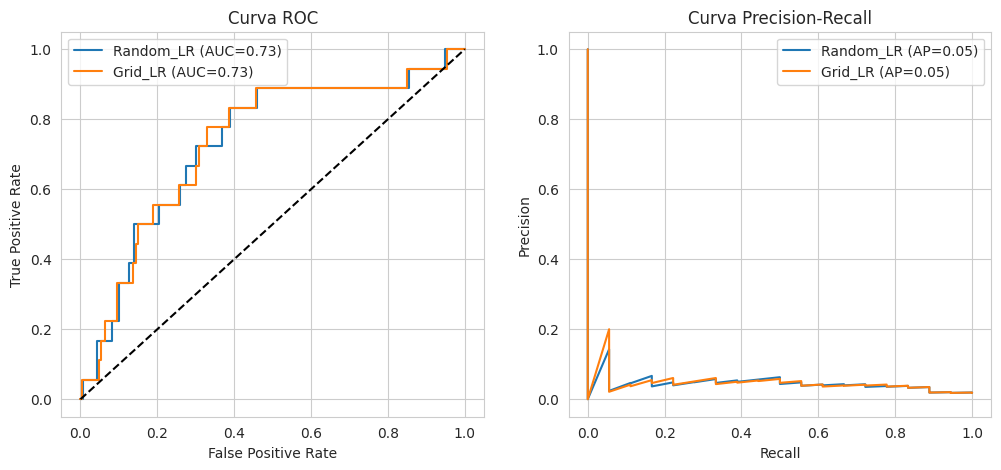

In [54]:
# Visualización de curvas ROC y PR
plt.figure(figsize=(12, 5))

# Subplot 1: ROC
plt.subplot(1, 2, 1)
for name, (cm, roc_auc, fpr, tpr, _, _, _) in evaluation_results.items():
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()

# Subplot 2: PR
plt.subplot(1, 2, 2)
for name, (_, _, _, _, precision, recall, ap_score) in evaluation_results.items():
    plt.plot(recall, precision, label=f'{name} (AP={ap_score:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.legend()

plt.show()

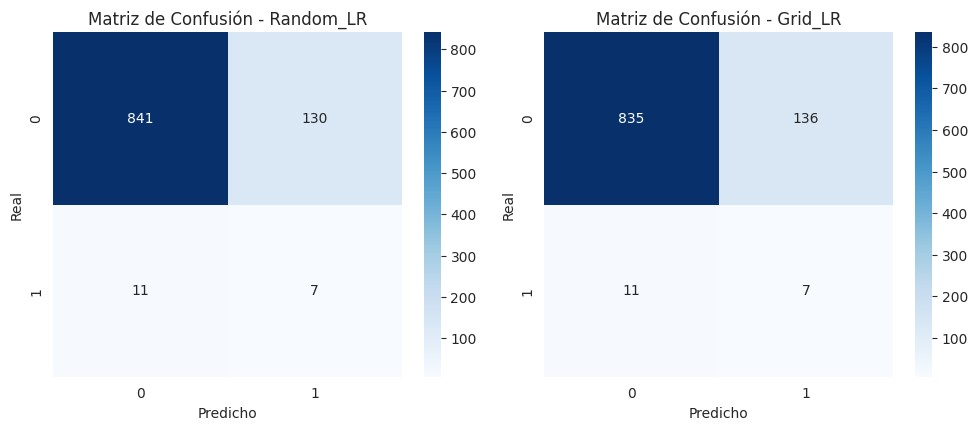

In [57]:
# Visualización de Matriz de Confusión
plt.figure(figsize=(10, 8))
for i, (name, (cm, _, _, _, _, _, _)) in enumerate(evaluation_results.items()):
    plt.subplot(2, 2, i+1)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f'Matriz de Confusión - {name}')
    plt.xlabel('Predicho')
    plt.ylabel('Real')

plt.tight_layout()
plt.show()

## Random Forest y XGBoost

In [ ]:
param_dist_brf = {
    'preprocessor': [
        ct_power_drop,
        ct_power_keep
    ],
    'resampler': [None],
    'clf': [BalancedRandomForestClassifier(random_state=42)],
    'clf__n_estimators': [100, 200, 500, 1000, 1500],  # Número de árboles
    'clf__max_depth': [None, 10, 30, 50],  # Profundidad de los árboles
    'clf__min_samples_split': [2, 4, 6],  # Min. muestras para dividir
    'clf__min_samples_leaf': [1, 3, 5],
    'clf__max_features': ['sqrt', 'log2', 0.5, 0.75],
    'clf__class_weight': ['balanced', 'balanced_subsample'],
    'clf__bootstrap': [True, False]
    }

random_brf = RandomizedSearchCV(
    pipeline_base,
    param_distributions=param_dist_brf,
    n_iter=1000,  # Prueba 30 combinaciones aleatorias
    scoring=scoring,
    refit='average_precision',
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=3
)

# Entrenar el modelo
random_brf.fit(X_train, y_train)

# Guardar el mejor modelo
best_model_brf = random_brf.best_estimator_
joblib.dump(best_model_brf, "best_BRF.pkl")

# Mostrar mejores parámetros y resultados
print("Mejores parámetros:", random_brf.best_params_)
print("Mejor puntuación (CV):", random_brf.best_score_)

Fitting 5 folds for each of 1000 candidates, totalling 5000 fits
Mejores parámetros: {'resampler': None, 'preprocessor': ColumnTransformer(transformers=[('num_sesgada',
                                 Pipeline(steps=[('power',
                                                  PowerTransformer())]),
                                 Index(['tasa_interes', 'monto_desembolso', 'saldo_credito',
       'monto_diferido_bs', 'interes_diferido_bs', 'monto_garantia_bs',
       'monto_favor_bs', 'numero_creditos', 'ingresos_anual', 'gastos_anual',
       'duracion_credito', 'ratio_gastos_ingresos', 'total_diferido'],
      dtype='ob...
                                 ['edad', 'cuotas_pactadas',
                                  'antiguedad_actividad',
                                  'periodo_pago_interes', 'pct_pagado']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_val

In [ ]:
from scipy.stats import uniform, randint

scale_pos_weight = sum(y_train == 0) / sum(y_train == 1) # Ajusta el peso de la clase minoritaria

param_grid_xgb = {
    'preprocessor': [
        ct_power_drop,
        ct_power_keep
    ],
    'resampler': resampling_strategies,
    'clf': [xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')],
    'clf__n_estimators': [50, 100, 200],
    'clf__learning_rate': [0.01, 0.1, 0.2],
    'clf__max_depth': [3, 6, 10],
    'clf__min_child_weight': [1, 3, 5],
    'clf__gamma': [0, 0.1, 0.5],
    'clf__subsample': [0.8, 1.0],
    'clf__colsample_bytree': [0.8, 1.0],
    'clf__reg_alpha': [0, 0.1, 1, 10],
    'clf__reg_lambda': [0, 1, 10],
    'clf__scale_pos_weight': [1, scale_pos_weight]
}

param_dist_xgb = {
    'preprocessor': [
        ct_power_drop,
        ct_power_keep
    ],
    'resampler': resampling_strategies,
    'clf': [xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')],
    'clf__n_estimators': randint(300, 400),
    'clf__learning_rate': uniform(0.01, 0.5),
    'clf__max_depth': randint(2, 7),
    'clf__min_child_weight': randint(1, 4),
    'clf__gamma': uniform(0, 0.4),
    'clf__subsample': uniform(0.8, 0.2),
    'clf__colsample_bytree': uniform(0.8, 0.2),
    'clf__reg_alpha': uniform(0, 10),
    'clf__reg_lambda': uniform(0, 10),
    'clf__scale_pos_weight': randint(50, 60)
}

random_xgb = RandomizedSearchCV(
    pipeline_base,
    param_distributions=param_dist_xgb,
    n_iter=2000,
    scoring=scoring,
    refit='average_precision',
    cv=5,
    n_jobs=-1,
    random_state=42
)

# Entrenar XGBoost
random_xgb.fit(X_train, y_train)

# Guardar el mejor modelo entrenado
best_model_xgb = random_xgb.best_estimator_
joblib.dump(best_model_xgb, "best_XGBoost_2000it_powerPipe_bal.pkl")

# Mostrar los mejores parámetros y puntuación
print("Mejores parámetros:", random_xgb.best_params_)
print("Mejor puntuación (CV):", random_xgb.best_score_)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:08:12] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Mejores parámetros: {'clf': XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...), 'clf__colsample_bytree': 0.9817187175832752, 'clf__gamma': 0.16423411950757558, 'clf__learning_rate': 0.06859214304531902, 'clf__max_depth': 7, 'clf__min_child_weight': 2, 'clf__n_estimators': 259, 'clf__reg_al

In [ ]:
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc, precision_recall_curve,
                             average_precision_score)
from sklearn.model_selection import cross_val_predict

# Cargar modelos entrenados
models = {
    'Random Forest': joblib.load("best_BRF.pkl"),
    'XGBoost_2000it_PP': joblib.load("best_XGBoost_2000it_powerPipe.pkl")
}

In [ ]:
# Almacenar resultados para evitar recomputación
evaluation_results = {name: evaluate_model(model, X_test, y_test) for name, model in models.items()}

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.98      0.75      0.85       971
           1       0.02      0.33      0.05        18

    accuracy                           0.75       989
   macro avg       0.50      0.54      0.45       989
weighted avg       0.97      0.75      0.84       989



/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:15:10] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:15:10] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:15:11] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:15:12] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:15:12] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.98      0.96      0.97       971
           1       0.03      0.06      0.04        18

    accuracy                           0.95       989
   macro avg       0.50      0.51      0.50       989
weighted avg       0.96      0.95      0.96       989



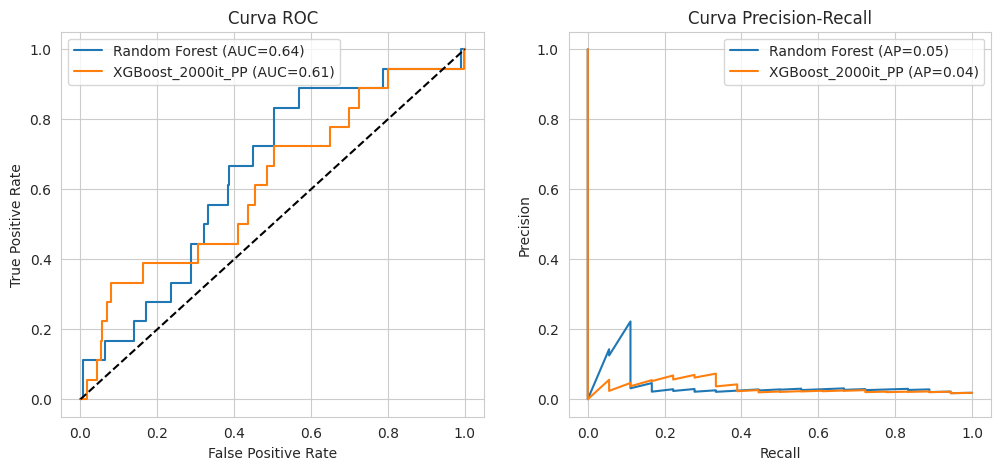

In [ ]:
# Visualización de curvas ROC y PR
plt.figure(figsize=(12, 5))

# Subplot 1: ROC
plt.subplot(1, 2, 1)
for name, (cm, roc_auc, fpr, tpr, _, _, _) in evaluation_results.items():
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()

# Subplot 2: PR
plt.subplot(1, 2, 2)
for name, (_, _, _, _, precision, recall, ap_score) in evaluation_results.items():
    plt.plot(recall, precision, label=f'{name} (AP={ap_score:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.legend()

plt.show()

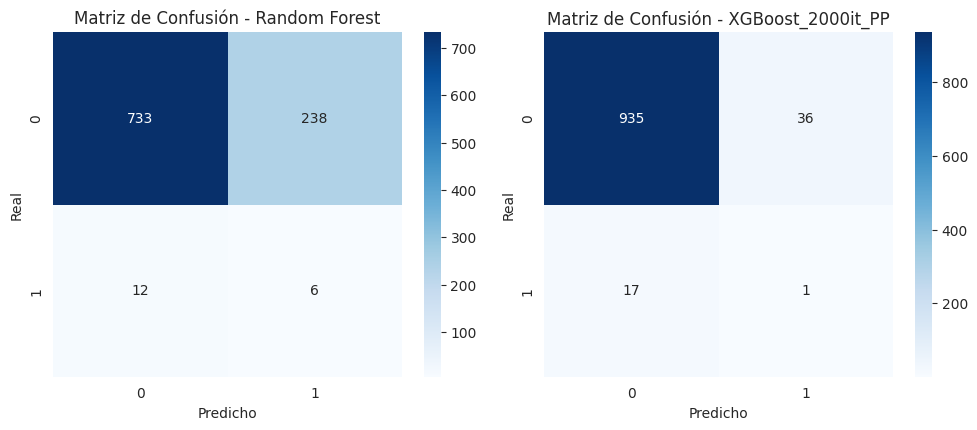

In [ ]:
# Visualización de Matriz de Confusión
plt.figure(figsize=(10, 8))
for i, (name, (cm, _, _, _, _, _, _)) in enumerate(evaluation_results.items()):
    plt.subplot(2, 2, i+1)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f'Matriz de Confusión - {name}')
    plt.xlabel('Predicho')
    plt.ylabel('Real')

plt.tight_layout()
plt.show()

# Red Neuronal Profunda

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - Precision: 0.0224 - Recall: 0.3225 - loss: 0.0521 - val_Precision: 0.0625 - val_Recall: 0.5000 - val_loss: 0.0327
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - Precision: 0.0469 - Recall: 0.3676 - loss: 0.0219 - val_Precision: 0.0000e+00 - val_Recall: 0.0000e+00 - val_loss: 0.0211
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - Precision: 0.1016 - Recall: 0.3599 - loss: 0.0182 - val_Precision: 0.0000e+00 - val_Recall: 0.0000e+00 - val_loss: 0.0140
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - Precision: 0.1580 - Recall: 0.3325 - loss: 0.0142 - val_Precision: 0.3333 - val_Recall: 0.0556 - val_loss: 0.0105
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - Precision: 0.2029 - Recall: 0.4046 - loss: 0.0099 - val_Precision: 0.5000 - val_Recall: 0.0556 - val_loss: 0.0084
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - Precision: 0.2453 - Recall: 0.2944 - loss: 0.0094 - val_Precision: 0.5000 - val_Recall: 0.0556 - val_loss

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


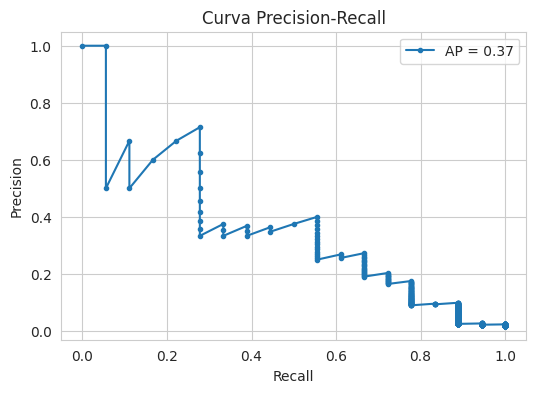

Mejor umbral basado en F1-score: 0.2842


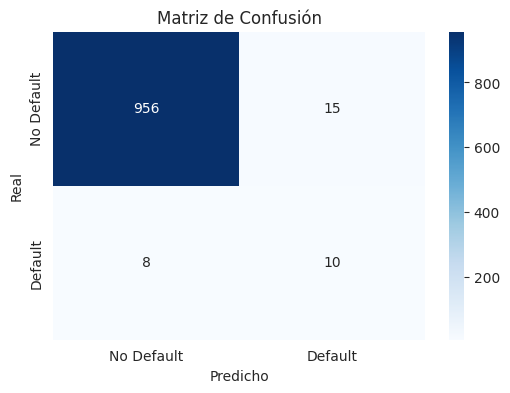

['best_threshold.pkl']

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, LeakyReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import precision_recall_curve, average_precision_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

ct_power_keep.fit(X_train)

X_train_transformed = ct_power_keep.transform(X_train)
X_test_transformed = ct_power_keep.transform(X_test)

def focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):
        y_pred = tf.keras.backend.clip(y_pred, 1e-7, 1 - 1e-7)
        pt = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
        loss = -alpha * (1 - pt) ** gamma * tf.keras.backend.log(pt)
        return tf.keras.backend.mean(loss)
    return loss

def plot_confusion_matrix(y_true, y_pred, threshold=0.5):
    y_pred_bin = (y_pred >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred_bin)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Default', 'Default'], yticklabels=['No Default', 'Default'])
    plt.xlabel('Predicho')
    plt.ylabel('Real')
    plt.title('Matriz de Confusión')
    plt.show()

def plot_precision_recall(y_true, y_pred):
    precision, recall, thresholds = precision_recall_curve(y_true, y_pred)
    avg_precision = average_precision_score(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    plt.plot(recall, precision, marker='.', label=f'AP = {avg_precision:.2f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Curva Precision-Recall')
    plt.legend()
    plt.show()

    # Encontrar el mejor umbral
    f1_scores = (2 * precision * recall) / (precision + recall + 1e-7)
    best_idx = np.argmax(f1_scores) if len(f1_scores) > 0 else 0
    best_threshold = thresholds[best_idx] if len(thresholds) > best_idx else 0.5
    print(f'Mejor umbral basado en F1-score: {best_threshold:.4f}')
    return best_threshold

classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}

model = Sequential([
    Dense(128, input_dim=X_train_transformed.shape[1]),
    BatchNormalization(),
    LeakyReLU(),
    Dropout(0.1),

    Dense(64),
    BatchNormalization(),
    LeakyReLU(),
    Dropout(0.1),

    Dense(32),
    BatchNormalization(),
    LeakyReLU(),
    Dropout(0.1),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss=focal_loss(),
    metrics=['Precision', 'Recall']
)

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train_transformed, y_train,
    epochs=100,
    batch_size=128,
    validation_data=(X_test_transformed, y_test),
    callbacks=[early_stopping],
    class_weight=class_weight_dict,
    verbose=1
)

model.save("modelo_nn_focal_loss.h5")

y_pred_probs = model.predict(X_test_transformed).ravel()
best_threshold = plot_precision_recall(y_test, y_pred_probs)
plot_confusion_matrix(y_test, y_pred_probs, threshold=best_threshold)

joblib.dump(best_threshold, "best_threshold.pkl")

In [ ]:
from tensorflow.keras.models import load_model
import joblib
import numpy as np
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_curve, auc
import matplotlib.pyplot as plt

# Cargar el modelo entrenado
model = load_model("modelo_nn_focal_loss.h5", custom_objects={'loss': focal_loss()})

# Cargar el umbral si quieres marcarlo luego (opcional)
best_threshold = joblib.load("best_threshold.pkl")


In [ ]:
# Asumiendo que ya tienes X_test_transformed y y_test cargados
y_pred_probs = model.predict(X_test_transformed).ravel()

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


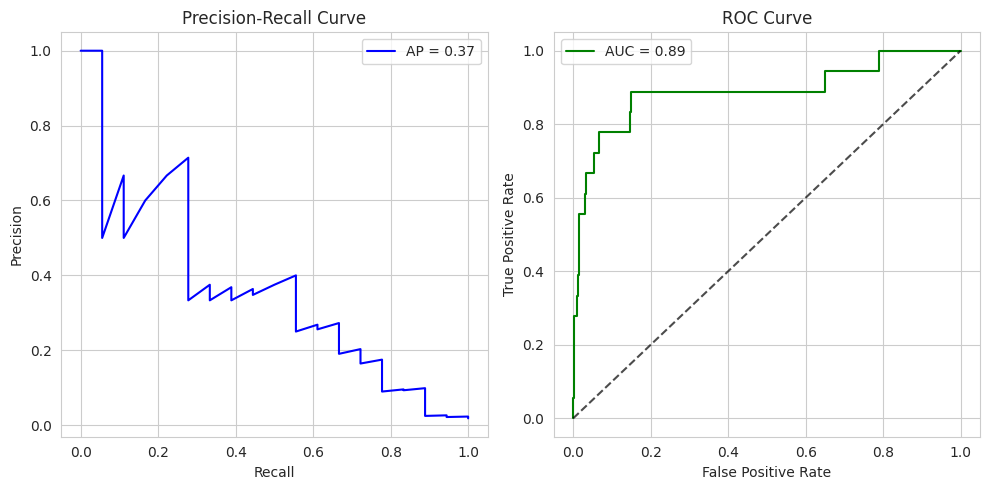

In [ ]:
from sklearn.metrics import roc_auc_score

# PR curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_probs)
avg_precision = average_precision_score(y_test, y_pred_probs)

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = roc_auc_score(y_test, y_pred_probs)

# Plot
plt.figure(figsize=(10, 5))

# PR Curve
plt.subplot(1, 2, 1)
plt.plot(recall, precision, label=f'AP = {avg_precision:.2f}', color='blue')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)

# ROC Curve
plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}', color='green')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.7)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()